# Data cleaning

In [30]:
import pandas as pd
from pathlib import Path
from functools import reduce

import os, warnings, gc, json, joblib, pprint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
DATA_DIR1 = Path(r'C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan')
files_0109 = {
    'Nozzle_Temp'       : 'Nozzle 1 Temp-data-2025-05-08 11_32_24.csv',
    'Injection_Time'    : 'Injection Time-data-2025-05-08 11_32_19.csv',
    'FeedThroat Temp'   : 'Feed Throat Temp-data-2025-05-08 11_32_35.csv',
    'Dosing Time'       : 'Dosing Time-data-2025-05-08 11_32_40.csv',
    'Barrel Zone 1 Temp': 'Barrel Zone 1 Temp-data-2025-05-08 11_32_29.csv',
    'Product_Thickness' : 'Product Thickness-data-2025-05-08 11_32_50.csv',
    'Outer_Diameter'    : 'Outer Diameter-data-2025-05-08 11_32_45.csv',
    'Inner_Diameter'    : 'Inner Diameter-data-2025-05-08 11_32_55.csv'
}


DATA_DIR2 = Path(r'C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\24 FEB')
files_0224 = {
    'Nozzle_Temp'       : 'Nozzle 1 Temp-data-2025-05-06 11_29_02.csv',
    'Injection_Time'    : 'Injection Time-data-2025-05-06 11_28_54.csv',
    'FeedThroat Temp'   : 'Feed Throat Temp-data-2025-05-06 11_29_11.csv',
    'Dosing Time'       : 'Dosing Time-data-2025-05-08 11_30_13.csv',
    'Barrel Zone 1 Temp': 'Barrel Zone 1 Temp-data-2025-05-06 11_29_07.csv',
    'Product_Thickness' : 'Product Thickness-data-2025-05-06 11_32_12.csv',
    'Outer_Diameter'    : 'Outer Diameter-data-2025-05-06 11_32_06.csv',
    'Inner_Diameter'    : 'Inner Diameter-data-2025-05-06 11_32_17.csv'
}


DATA_DIR3 = Path(r'C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\27 Mar')
files_0327 = {
    'Nozzle_Temp'       : 'Nozzle 1 Temp-data-2025-05-08 11_29_13.csv',
    'Injection_Time'    : 'Injection Time-data-2025-05-08 11_29_08.csv',
    'FeedThroat Temp'   : 'Feed Throat Temp-data-2025-05-08 11_29_24.csv',
    'Dosing Time'       : 'Dosing Time-data-2025-05-08 11_29_31.csv',
    'Barrel Zone 1 Temp': 'Barrel Zone 1 Temp-data-2025-05-08 11_29_18.csv',
    'Product_Thickness' : 'Product Thickness-data-2025-05-08 11_28_57.csv',
    'Outer_Diameter'    : 'Outer Diameter-data-2025-05-08 11_28_50.csv',
    'Inner_Diameter'    : 'Inner Diameter-data-2025-05-08 11_29_02.csv'
}

In [32]:

# Correspondence between folders and files for three days
# a list that combine DATA_DIRS and files_data (dictionary)

DATA_DIRS = [
    (Path(r'C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan'), files_0109),
    (Path(r'C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\24 FEB'), files_0224),
    (Path(r'C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\27 Mar'), files_0327)
]

inputs  = ['Nozzle_Temp','Injection_Time','FeedThroat Temp',
           'Dosing Time','Barrel Zone 1 Temp']
targets = ['Product_Thickness','Outer_Diameter','Inner_Diameter']

'''
cols -> ['Nozzle_Temp', 'Injection_Time', 'FeedThroat Temp', 'Dosing Time', 'Barrel Zone 1 Temp',
       'Product_Thickness', 'Outer_Diameter', 'Inner_Diameter']
       
'''

cols = inputs + targets

# Store the merged DataFrame for each day
merged_days = []

# Process each day, and get a folder path and the corresponding dictionary of files for that day each time
for DATA_DIR, files in DATA_DIRS:
    dataframes = {} # a dictionary
    # Process each column in order (inputs + targets)
    for name in cols:
        # Use Path objects to assemble a complete file path
        """
        DATA_DIR = C:\\Users\\aaron\\OneDrive\\桌面\\2024 sem2\\intern\\JE\\clean data\\09 Jan
        files[Nozzle_Temp] = Nozzle 1 Temp-data-2025-05-08 11_32_24.csv
        C:\\Users\\aaron\\OneDrive\\桌面\\2024 sem2\\intern\\JE\\clean data\\09 Jan\\Nozzle 1 Temp-data-2025-05-08 11_32_24.csv
        """
        
        path = DATA_DIR / files[name]
        # Read csv file into DataFrame
        df = pd.read_csv(path)
        
        # dayfirst=True to ensure the correct "day/month/year" format
        df['Time'] = pd.to_datetime(df['Time'], dayfirst=True)
        
        # Check for duplicate time points, return True (bool) if there is any duplicated items.
        duplicated = df['Time'].duplicated(keep=False)
        
        # any() function is used to determine whether all the given iterable parameters are False, then return False.
        # if one is True, then return True
        if duplicated.any():
            print(f"{name} ({DATA_DIR}) is repeated in time *******，{duplicated.sum()} in total")
            # .loc -> df.loc[conditional filtering, specified column]
            # return the all rows where duplicated == True
            # .value_counts() -> Count the number of times each unique time occurs
            print(df.loc[duplicated, 'Time'].value_counts())
        else:
            print(f"{name} ({DATA_DIR}) is not repeated in time")
            
        # Clean up duplicates
        # This step is to deal with duplicate time points. 
        # Delete duplicate rows based on the time column ('Time') and keep the first record of each time point.
        df = df.drop_duplicates(subset='Time', keep='first')

        # Set Time as an index to facilitate subsequent merging.
        df = df.set_index('Time')
        
        # [c for c in df.columns if c != 'Time']: Filter out non-time columns
        # [0]: Get the first non-time column
        # e.g. 'Nozzle_Temp ( °C)'
        value_col = [c for c in df.columns if c != 'Time'][0]
        
        # rename it by dictionary {'Nozzle_Temp ( °C)':Nozzle_Temp}
        # 'Nozzle_Temp ( °C)' - > Nozzle_Temp
        df = df.rename(columns={value_col: name})
        
        # df[[name]]: Returns a DataFrame (a two-dimensional table)
        """
        df[name] → Series: [215, ...]

        df[[name]] → DataFrame:
        | Nozzle_Temp |
        |-------------|
        | 215         |
        | ...         |
        """
        dataframes[name] = df[[name]]

        
    # Merge all columns for the day
    # dataframes.values() will get you a list of all the fields DataFrames you just sorted
    # each DataFrame is indexed by Time.
    # and remember dataframes is a dictionary and its value is a dataframe
    """
    Merge all DataFrames in order using an "outer join" method, with the main axis of the merge being the index (i.e., Time).
    Outer join will retain all the time points that have appeared, and the mismatched fields will be NaN.
    This ensures that all fields at each time point are merged in, and no data is missed.
    Finally, merged_day is the complete DataFrame after all the fields of that day are merged.
    """

    merged_day = reduce(lambda left, right: left.join(right, how='outer'), dataframes.values())
    
    # sort_values('Time') will sort by the value of the Time field, ensuring that the data is sorted in chronological order.
    # reset_index(drop=True) will renumber the sorted indexes and not keep the old indexes.
    merged_day = merged_day.reset_index()
    merged_day = merged_day.sort_values('Time').reset_index(drop=True)
    merged_days.append(merged_day)

# Three days of data are combined into one summary table
merged_total = pd.concat(merged_days, ignore_index=True)
merged_total = merged_total.sort_values('Time').reset_index(drop=True)

print("The merged_total table after the merge is in shape：", merged_total.shape)
merged_total.head()

Nozzle_Temp (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
Injection_Time (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
FeedThroat Temp (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
Dosing Time (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
Barrel Zone 1 Temp (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
Product_Thickness (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
Outer_Diameter (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
Inner_Diameter (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\09 Jan) is not repeated in time
Nozzle_Temp (C:\Users\aaron\OneDrive\桌面\2024 sem2\intern\JE\clean data\24 FEB) is not repeated in time
Injection_Time (C:\Users\aaron\OneDrive\桌面\2024

,Time,Nozzle_Temp,Injection_Time,FeedThroat Temp,Dosing Time,Barrel Zone 1 Temp,Product_Thickness,Outer_Diameter,Inner_Diameter
0,2025-01-09 10:37:00,326.0,1.48,57.9,6.27,310.0,NaN,NaN,NaN
1,2025-01-09 10:37:30,326.0,1.48,57.9,6.06,310.0,10.03,9.95,5.11
2,2025-01-09 10:38:00,326.0,1.48,57.9,6.49,310.0,10.01,9.95,5.11
3,2025-01-09 10:38:30,326.0,1.48,57.9,5.88,310.0,NaN,NaN,NaN
4,2025-01-09 10:39:00,326.0,1.48,57.9,5.88,309.0,NaN,NaN,NaN


In [18]:
merged_total.to_csv('merged_total.csv', index=False, encoding='utf-8-sig')
print("done")

done


In [33]:
# 1. Calculate the number of original rows in each file of inputs and targets (taking three days of data as an example)
input_rows = []
target_rows = []

for DATA_DIR, files in DATA_DIRS:
    input_rows.extend([len(pd.read_csv(DATA_DIR / files[name])) for name in inputs])
    target_rows.extend([len(pd.read_csv(DATA_DIR / files[name])) for name in targets])

print(f"inputs Original total number of rows: {input_rows}, {sum(input_rows)} in total")
print(f"targets Original total number of rows: {target_rows}, {sum(target_rows)} in total")

# 2. Find rows where any field is NaN after merging
null_rows = merged_total[merged_total.isnull().any(axis=1)]

# 3. Create null_value_time and keep only the Time field
null_value_time = null_rows[['Time']].copy()

# 4. Display the total number of rows with missing values
print(f"Number of rows with missing values: {len(null_value_time)}")
null_value_time

inputs Original total number of rows: [984, 984, 984, 984, 984, 797, 797, 797, 821, 797, 957, 957, 957, 957, 957], 13714 in total
targets Original total number of rows: [1068, 1068, 1068, 869, 869, 869, 1012, 1012, 1012], 8847 in total
Number of rows with missing values: 298


,Time
0,2025-01-09 10:37:00
3,2025-01-09 10:38:30
4,2025-01-09 10:39:00
25,2025-01-09 10:49:30
36,2025-01-09 10:55:00
...,...
3000,2025-03-27 17:41:00
3001,2025-03-27 17:42:30
3002,2025-03-27 17:45:00
3003,2025-03-27 17:45:30


In [20]:
merged_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3005 entries, 0 to 3004
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Time                3005 non-null   datetime64[ns]
 1   Nozzle_Temp         2738 non-null   float64       
 2   Injection_Time      2738 non-null   float64       
 3   FeedThroat Temp     2738 non-null   float64       
 4   Dosing Time         2762 non-null   float64       
 5   Barrel Zone 1 Temp  2738 non-null   float64       
 6   Product_Thickness   2949 non-null   float64       
 7   Outer_Diameter      2949 non-null   float64       
 8   Inner_Diameter      2949 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 211.4 KB


In [21]:
merged_total.isna().sum()

Time                    0
Nozzle_Temp           267
Injection_Time        267
FeedThroat Temp       267
Dosing Time           243
Barrel Zone 1 Temp    267
Product_Thickness      56
Outer_Diameter         56
Inner_Diameter         56
dtype: int64

In [34]:
# Create complete_df by removing rows with any null values
complete_df_total = merged_total.dropna().reset_index(drop=True)

# Verify the new dataset
print(f"Complete dataset shape: {complete_df_total.shape}")
print("\nMissing values per column:")
print(complete_df_total.isna().sum())

complete_df_total

Complete dataset shape: (2707, 9)

Missing values per column:
Time                  0
Nozzle_Temp           0
Injection_Time        0
FeedThroat Temp       0
Dosing Time           0
Barrel Zone 1 Temp    0
Product_Thickness     0
Outer_Diameter        0
Inner_Diameter        0
dtype: int64


,Time,Nozzle_Temp,Injection_Time,FeedThroat Temp,Dosing Time,Barrel Zone 1 Temp,Product_Thickness,Outer_Diameter,Inner_Diameter
0,2025-01-09 10:37:30,326.0,1.48,57.9,6.06,310.0,10.03,9.95,5.11
1,2025-01-09 10:38:00,326.0,1.48,57.9,6.49,310.0,10.01,9.95,5.11
2,2025-01-09 10:39:30,326.0,1.48,57.9,6.02,309.0,10.03,9.95,5.12
3,2025-01-09 10:40:00,326.0,1.48,57.9,6.34,309.0,10.04,9.95,5.12
4,2025-01-09 10:40:30,326.0,1.48,57.9,5.54,309.0,10.03,9.95,5.11
...,...,...,...,...,...,...,...,...,...
2702,2025-03-27 16:38:30,328.0,1.35,72.2,21.00,313.0,10.02,9.94,5.12
2703,2025-03-27 16:39:00,328.0,1.35,72.2,21.50,313.0,10.02,9.95,5.12
2704,2025-03-27 16:40:00,328.0,1.35,72.2,22.00,312.0,10.02,9.95,5.12
2705,2025-03-27 16:40:30,328.0,1.35,72.2,22.00,312.0,10.00,9.94,5.12


In [23]:
complete_df_total.to_csv('complete_df_total.csv', index=False, encoding='utf-8-sig')
print("done")

done


In [24]:
data_proportion = 2707/(3004+1)
print(f"data proportion:2707/3005 = {round(data_proportion, 4)}")
print("complete_df_total is used to ensures results reflect the observed data’s true distribution without imputation artifacts.")
print("merged_total is used to preserves sample size and avoids extreme value bias.")

data proportion:2707/3005 = 0.9008
complete_df_total is used to ensures results reflect the observed data’s true distribution without imputation artifacts.
merged_total is used to preserves sample size and avoids extreme value bias.


# Statistical analysis

In [25]:
merged_total.describe()

,Nozzle_Temp,Injection_Time,FeedThroat Temp,Dosing Time,Barrel Zone 1 Temp,Product_Thickness,Outer_Diameter,Inner_Diameter
count,2738.000000,2738.000000,2738.000000,2762.000000,2738.000000,2949.000000,2949.000000,2949.000000
mean,327.348064,1.422557,65.413148,6.746140,310.025201,10.018433,9.947993,5.116935
std,0.484806,0.041411,5.653480,1.701061,0.327333,0.017107,0.004568,0.004619
min,326.000000,1.350000,57.300000,5.100000,309.000000,9.940000,9.900000,5.110000
25%,327.000000,1.390000,60.900000,6.240000,310.000000,10.010000,9.950000,5.110000
50%,327.000000,1.400000,64.000000,6.560000,310.000000,10.020000,9.950000,5.120000
75%,328.000000,1.470000,71.500000,6.880000,310.000000,10.030000,9.950000,5.120000
max,328.000000,1.490000,75.900000,22.000000,313.000000,10.060000,9.960000,5.130000


In [26]:
complete_df_total.describe()

,Nozzle_Temp,Injection_Time,FeedThroat Temp,Dosing Time,Barrel Zone 1 Temp,Product_Thickness,Outer_Diameter,Inner_Diameter
count,2707.000000,2707.000000,2707.00000,2707.000000,2707.000000,2707.000000,2707.000000,2707.000000
mean,327.344293,1.423000,65.37669,6.630665,310.022904,10.018515,9.947972,5.116989
std,0.481406,0.041076,5.64685,1.110922,0.322006,0.016887,0.004612,0.004596
min,326.000000,1.350000,57.30000,5.100000,309.000000,9.940000,9.900000,5.110000
25%,327.000000,1.390000,60.90000,6.230000,310.000000,10.010000,9.950000,5.110000
50%,327.000000,1.400000,64.00000,6.560000,310.000000,10.020000,9.950000,5.120000
75%,328.000000,1.470000,71.50000,6.860000,310.000000,10.030000,9.950000,5.120000
max,328.000000,1.490000,75.90000,22.000000,313.000000,10.060000,9.960000,5.130000


# Visually analyze the relationship between multiple input parameters and target parameters

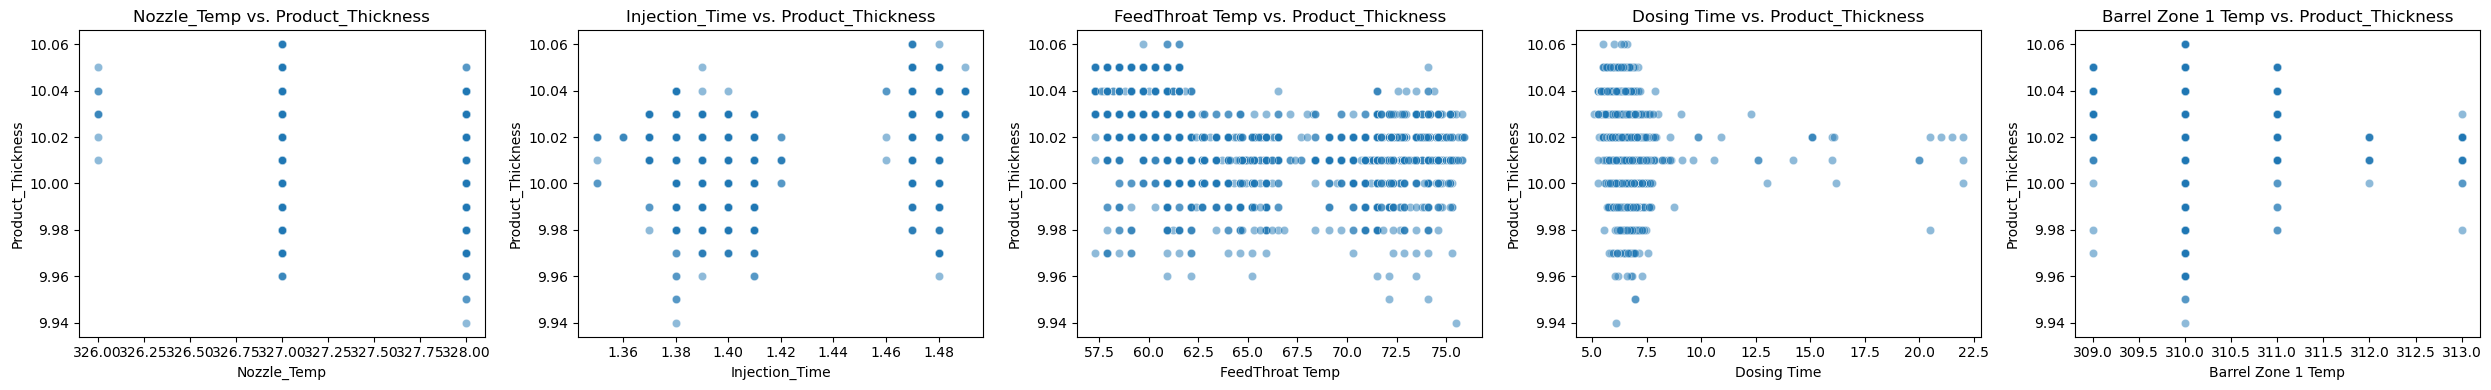

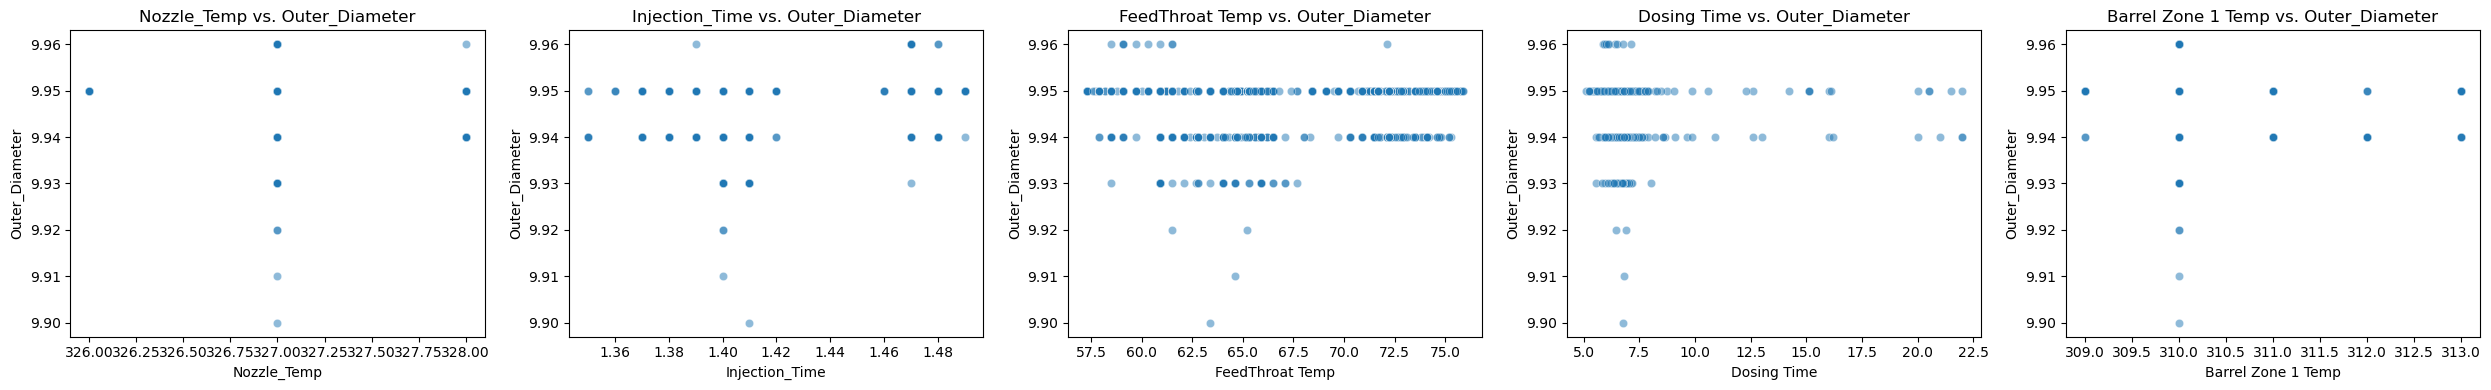

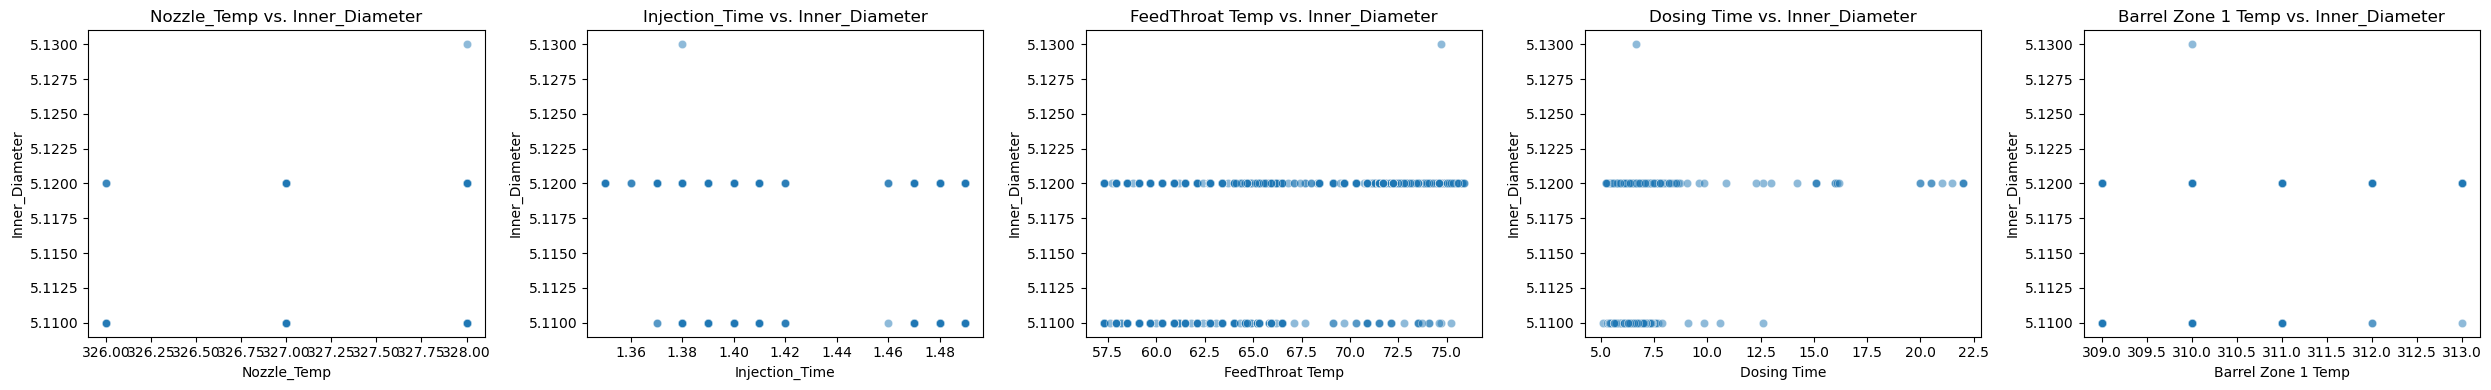

In [43]:
inputs  = ['Nozzle_Temp','Injection_Time','FeedThroat Temp','Dosing Time','Barrel Zone 1 Temp']
targets = ['Product_Thickness','Outer_Diameter','Inner_Diameter']


df = complete_df_total

for target in targets:
    fig, axes = plt.subplots(1, len(inputs), figsize=(5*len(inputs), 4))
    for i, input_col in enumerate(inputs):
        ax = axes[i]
        sns.scatterplot(x=df[input_col], y=df[target], ax=ax, alpha=0.5)
        ax.set_xlabel(input_col)
        ax.set_ylabel(target)
        ax.set_title(f'{input_col} vs. {target}')
    plt.tight_layout()
    plt.show()

# Correlation

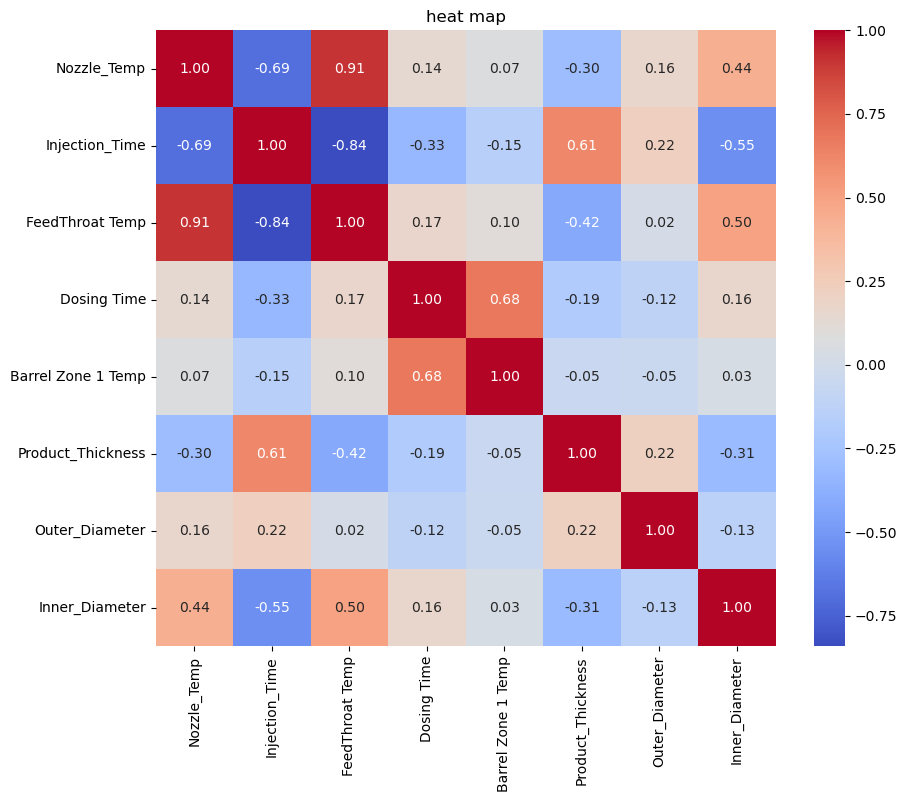

In [35]:
# calculate correlation matrix
corr_matrix = complete_df_total[[
    'Nozzle_Temp', 'Injection_Time', 'FeedThroat Temp',
    'Dosing Time', 'Barrel Zone 1 Temp',
    'Product_Thickness', 'Outer_Diameter', 'Inner_Diameter'
]].corr()
'''
print("correlation matrix：")
print(corr_matrix)
'''
# heat map with seaborn 
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('heat map')
plt.show()

Spearman correlation matrix：
                    Nozzle_Temp  Injection_Time  FeedThroat Temp  Dosing Time  \
Nozzle_Temp            1.000000       -0.820484         0.819084     0.245637   
Injection_Time        -0.820484        1.000000        -0.905204    -0.450106   
FeedThroat Temp        0.819084       -0.905204         1.000000     0.335840   
Dosing Time            0.245637       -0.450106         0.335840     1.000000   
Barrel Zone 1 Temp     0.077718       -0.148702         0.132729     0.113961   
Product_Thickness     -0.313925        0.544964        -0.489355    -0.427073   
Outer_Diameter         0.163165        0.100308        -0.077489    -0.222109   
Inner_Diameter         0.435948       -0.519897         0.503435     0.286070   

                    Barrel Zone 1 Temp  Product_Thickness  Outer_Diameter  \
Nozzle_Temp                   0.077718          -0.313925        0.163165   
Injection_Time               -0.148702           0.544964        0.100308   
FeedThroat

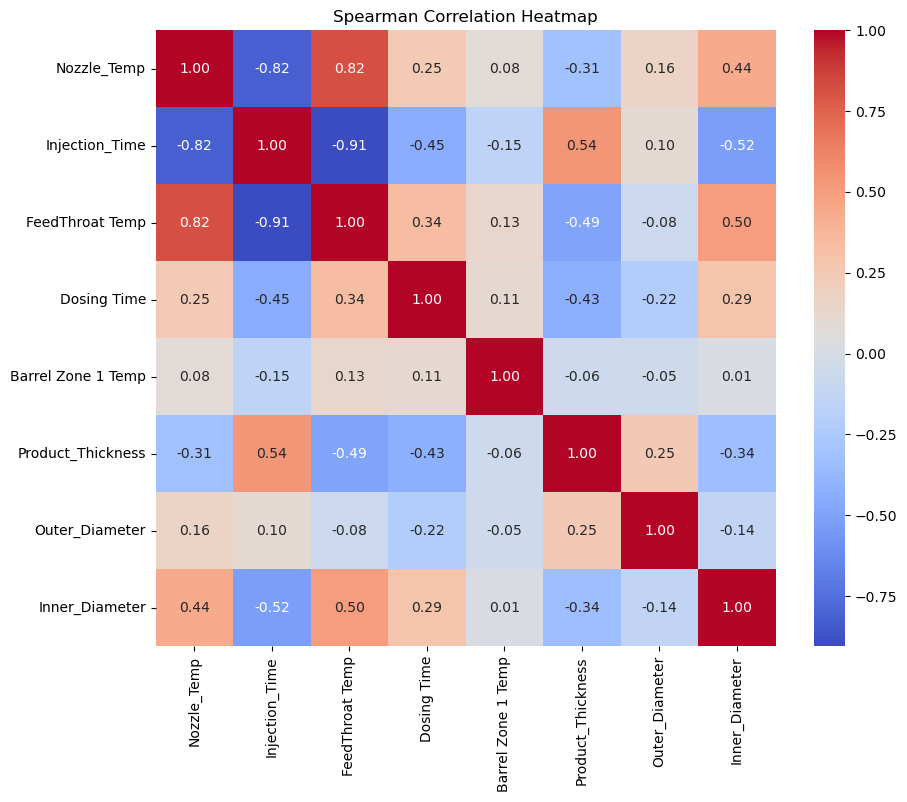

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


corr_matrix = complete_df_total[[
    'Nozzle_Temp', 'Injection_Time', 'FeedThroat Temp',
    'Dosing Time', 'Barrel Zone 1 Temp',
    'Product_Thickness', 'Outer_Diameter', 'Inner_Diameter'
]].corr(method='spearman')  

print("Spearman correlation matrix：")
print(corr_matrix)


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Heatmap')
plt.show()

# Outlier analysis


=== Product_Thickness ANALYSIS ===


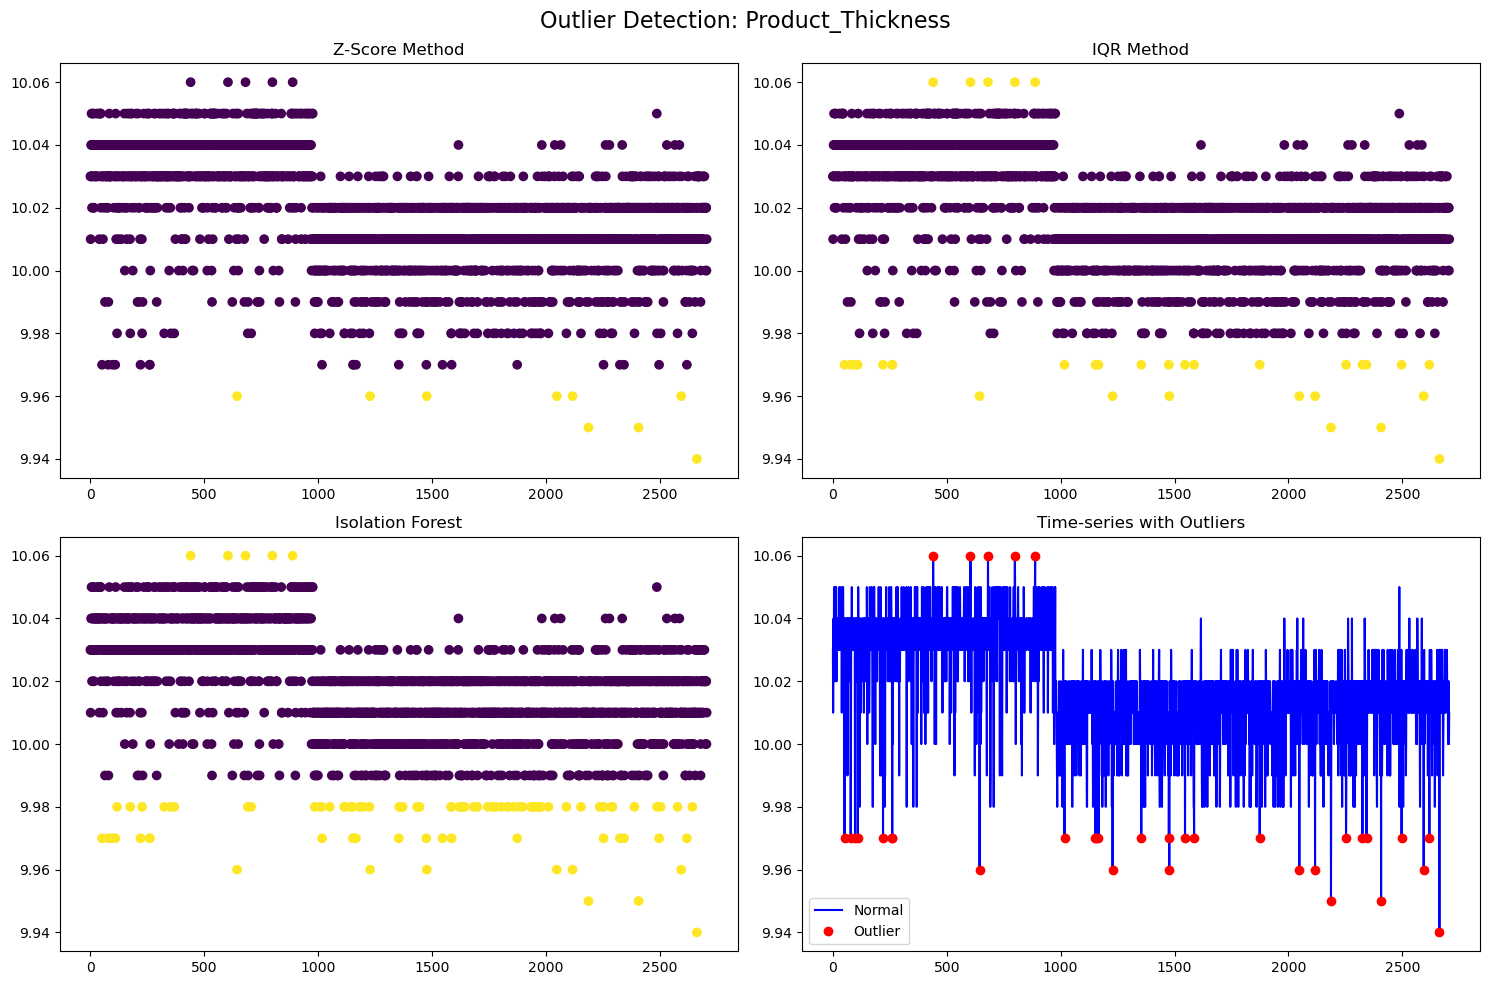


=== Outer_Diameter ANALYSIS ===


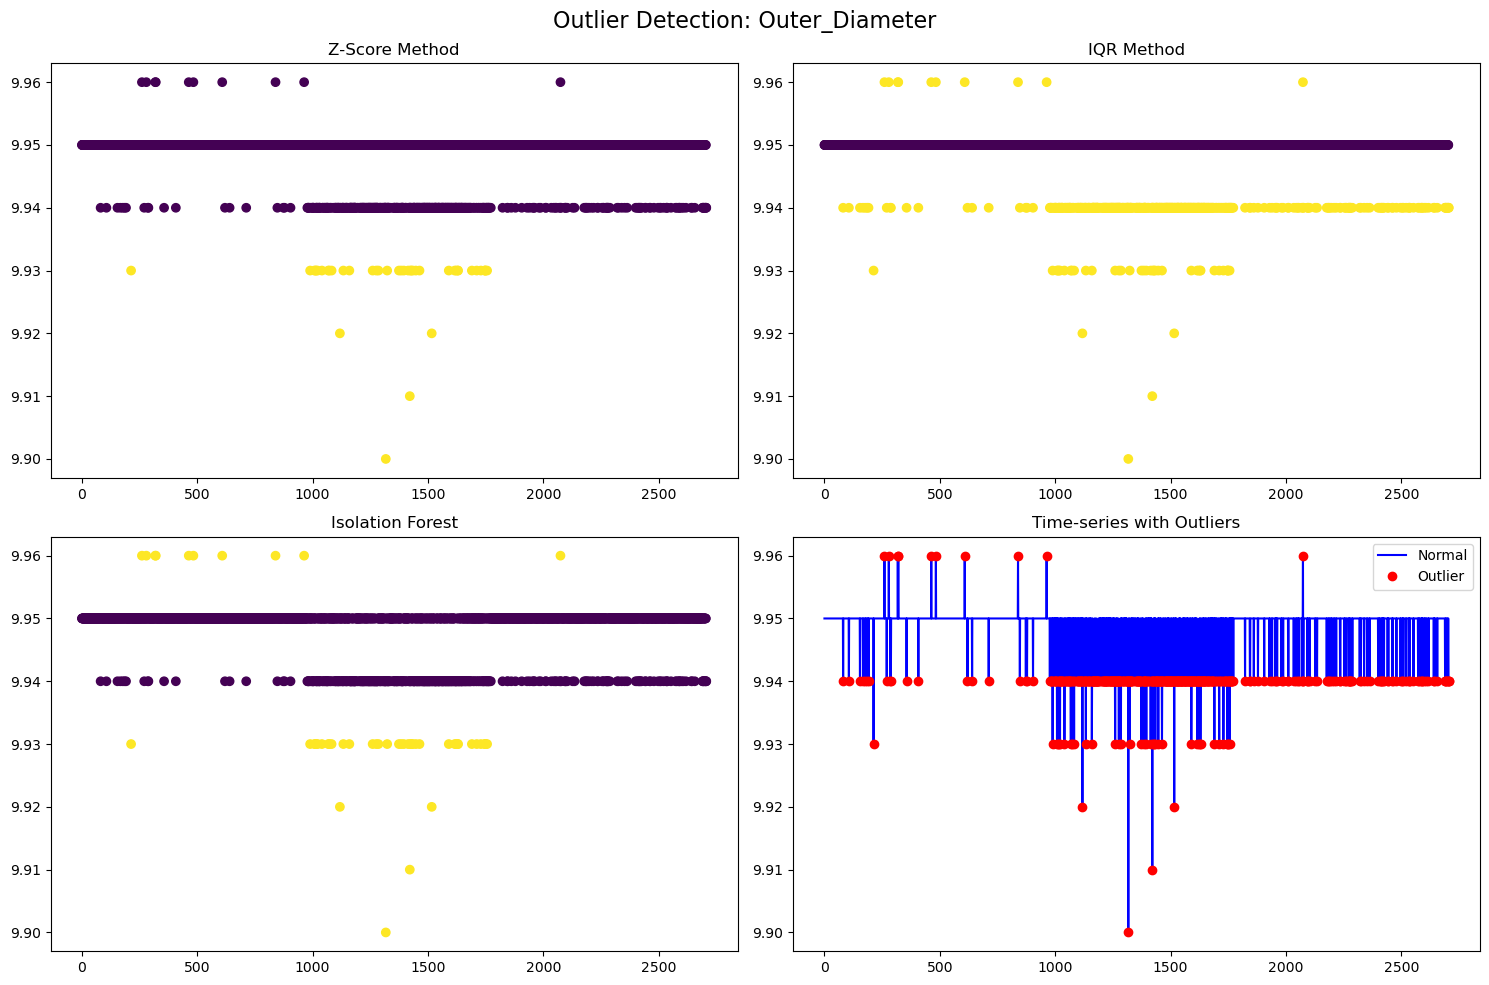


=== Inner_Diameter ANALYSIS ===


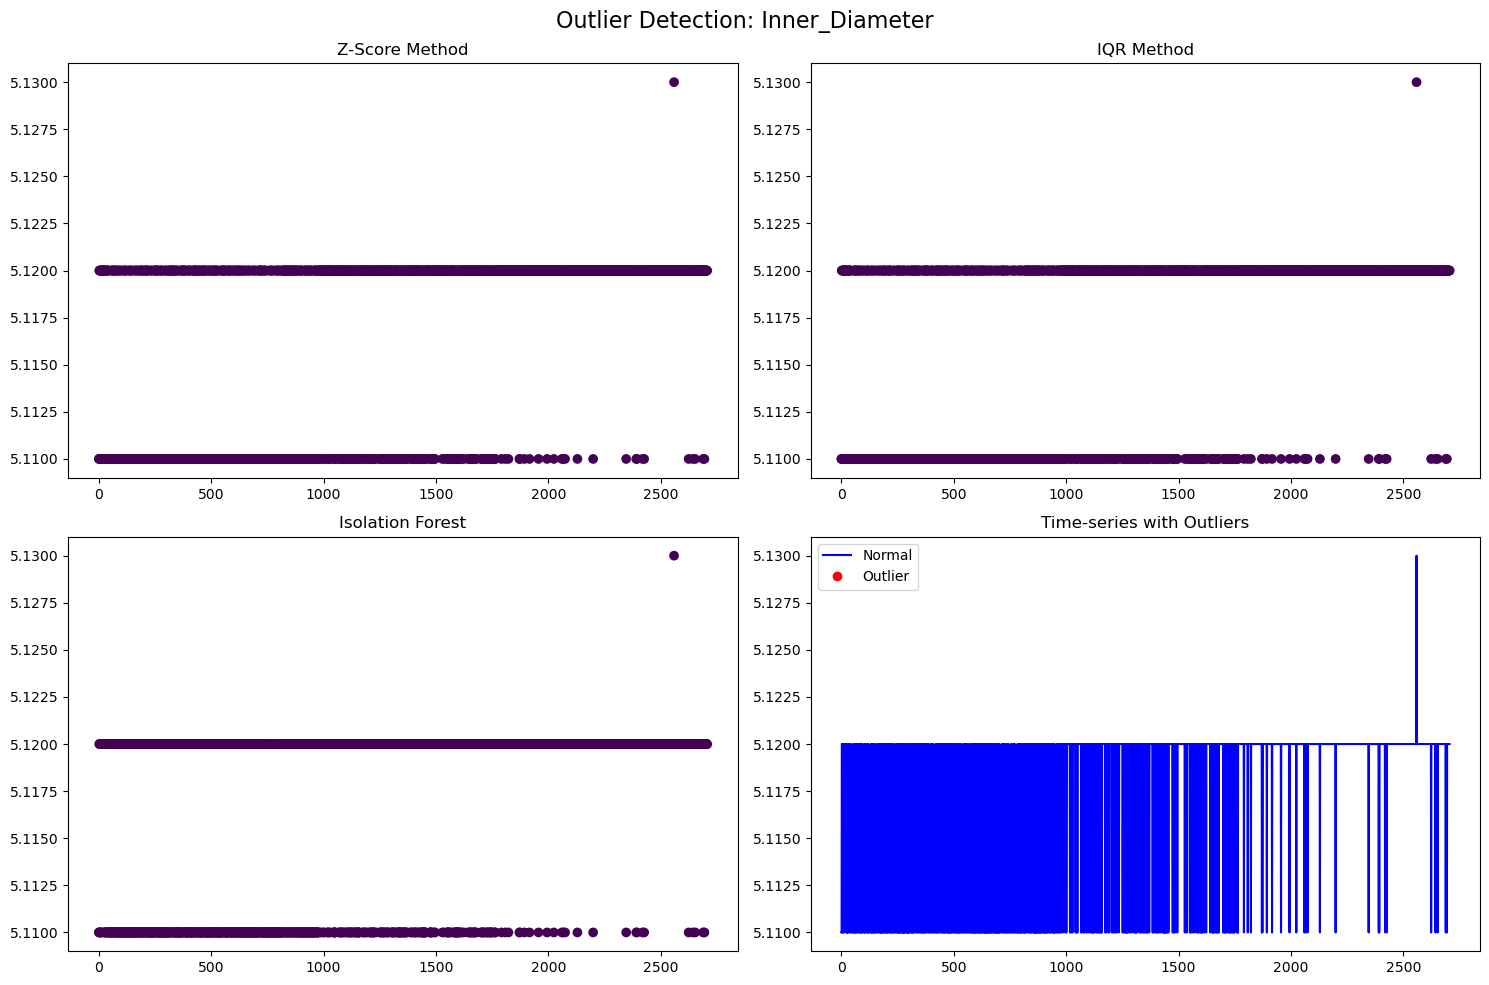

In [36]:
from scipy import stats
from sklearn.ensemble import IsolationForest

def manufacturing_outlier_analysis(df, variable):
    """Outlier detection for manufacturing process variables"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Outlier Detection: {variable}', fontsize=16)
    
    # 1. Z-Score Method
    z_scores = np.abs(stats.zscore(df[variable]))
    z_outliers = z_scores > 3
    axes[0,0].scatter(df.index, df[variable], c=z_outliers, cmap='viridis')
    axes[0,0].set_title('Z-Score Method')
    
    # 2. IQR Method
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = (df[variable] < (Q1 - 1.5 * IQR)) | (df[variable] > (Q3 + 1.5 * IQR))
    axes[0,1].scatter(df.index, df[variable], c=iqr_outliers, cmap='viridis')
    axes[0,1].set_title('IQR Method')
    
    # 3. Isolation Forest
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    iso_outliers = iso_forest.fit_predict(df[[variable]]) == -1
    axes[1,0].scatter(df.index, df[variable], c=iso_outliers, cmap='viridis')
    axes[1,0].set_title('Isolation Forest')
    
    # 4. Time-series Visualization
    axes[1,1].plot(df.index, df[variable], 'b-', label='Normal')
    axes[1,1].plot(df[iqr_outliers].index, df[variable][iqr_outliers], 'ro', label='Outlier')
    axes[1,1].set_title('Time-series with Outliers')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return {
        'z_score': z_outliers,
        'iqr': iqr_outliers,
        'isolation_forest': iso_outliers
    }

# Analyze each quality dimension
for dimension in ['Product_Thickness', 'Outer_Diameter', 'Inner_Diameter']:
    print(f"\n=== {dimension} ANALYSIS ===")
    manufacturing_outlier_analysis(complete_df_total, dimension)

Number of outliers in Product_Thickness (Isolation Forest): 95
Number of normal samples: 2612


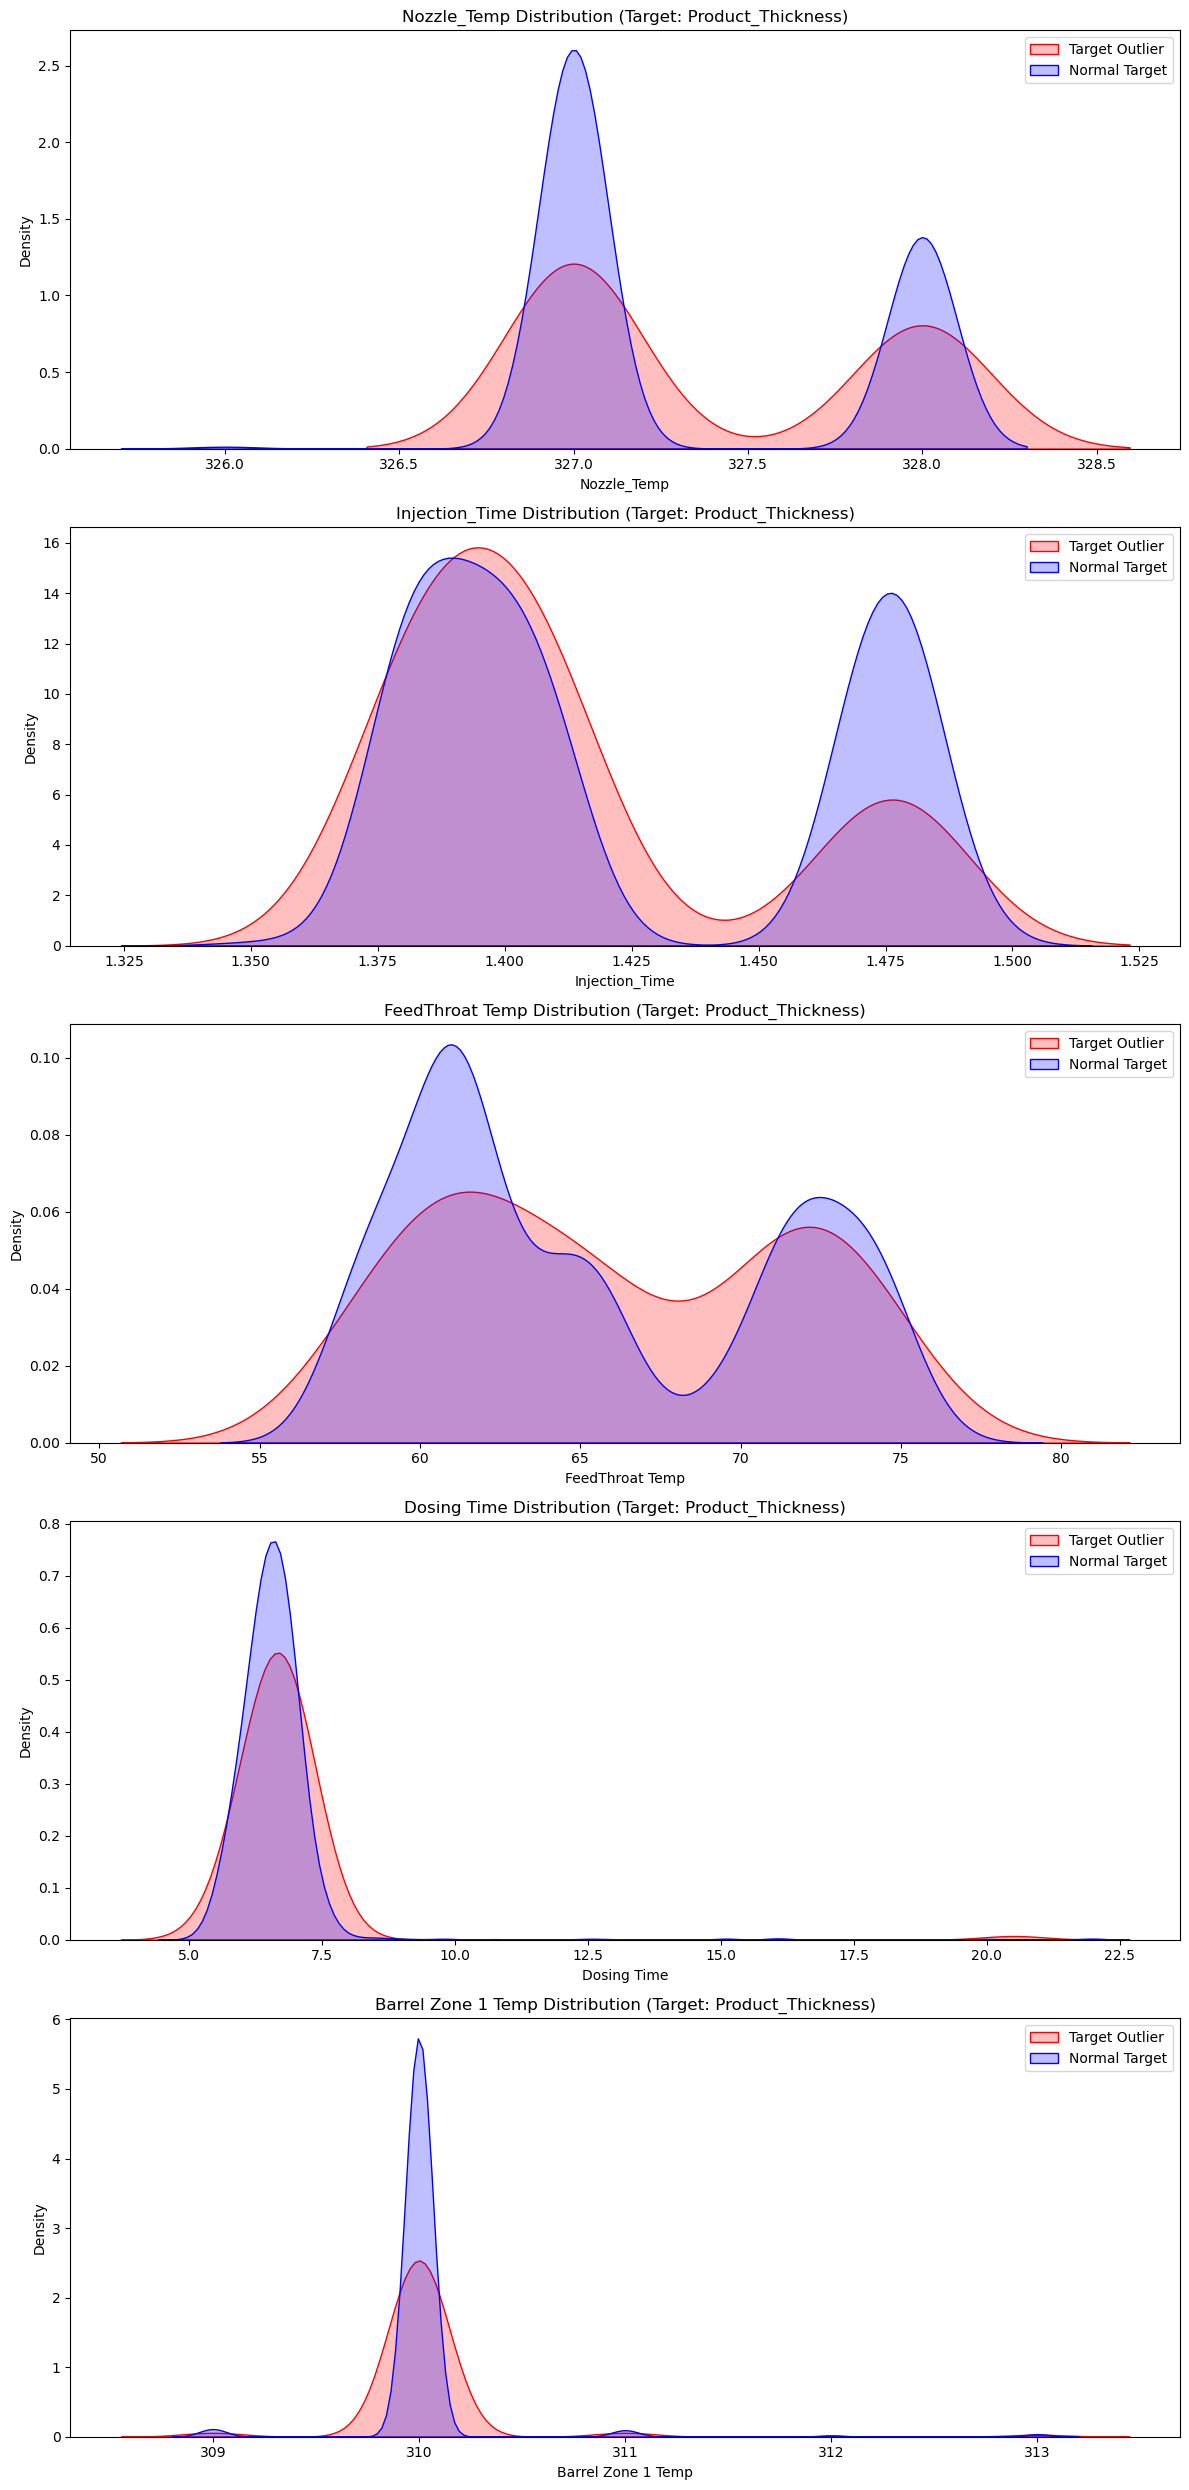

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

def analyze_input_distributions_for_target_outliers_iforest(df, target, inputs):
    # 1. Identify outliers in the target variable using Isolation Forest
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    outlier_flag = iso_forest.fit_predict(df[[target]]) == -1

    # 2. Split the data
    outlier_data = df[outlier_flag]
    normal_data = df[~outlier_flag]

    print(f"Number of outliers in {target} (Isolation Forest): {outlier_data.shape[0]}")
    print(f"Number of normal samples: {normal_data.shape[0]}")

    # 3. Plot input distributions for outlier vs normal target
    n_inputs = len(inputs)
    fig, axes = plt.subplots(n_inputs, 1, figsize=(12, 5 * n_inputs))
    if n_inputs == 1:
        axes = [axes]
    for i, param in enumerate(inputs):
        # Use histogram if outlier_data[param] has too few or identical values
        if len(outlier_data[param].unique()) > 1 and len(outlier_data[param]) > 2:
            sns.kdeplot(outlier_data[param], ax=axes[i], label='Target Outlier', fill=True, color='r')
        else:
            axes[i].hist(outlier_data[param], bins=5, alpha=0.6, label='Target Outlier', color='r', density=True)
        sns.kdeplot(normal_data[param], ax=axes[i], label='Normal Target', fill=True, color='b')
        axes[i].set_title(f'{param} Distribution (Target: {target})')
        axes[i].set_xlabel(param)
        axes[i].legend()
    plt.tight_layout()
    plt.show()



inputs  = ['Nozzle_Temp','Injection_Time','FeedThroat Temp','Dosing Time','Barrel Zone 1 Temp']
target = 'Product_Thickness'
analyze_input_distributions_for_target_outliers_iforest(complete_df_total, target, inputs)


Number of outliers in Outer_Diameter (Isolation Forest): 51
Number of normal samples: 2656


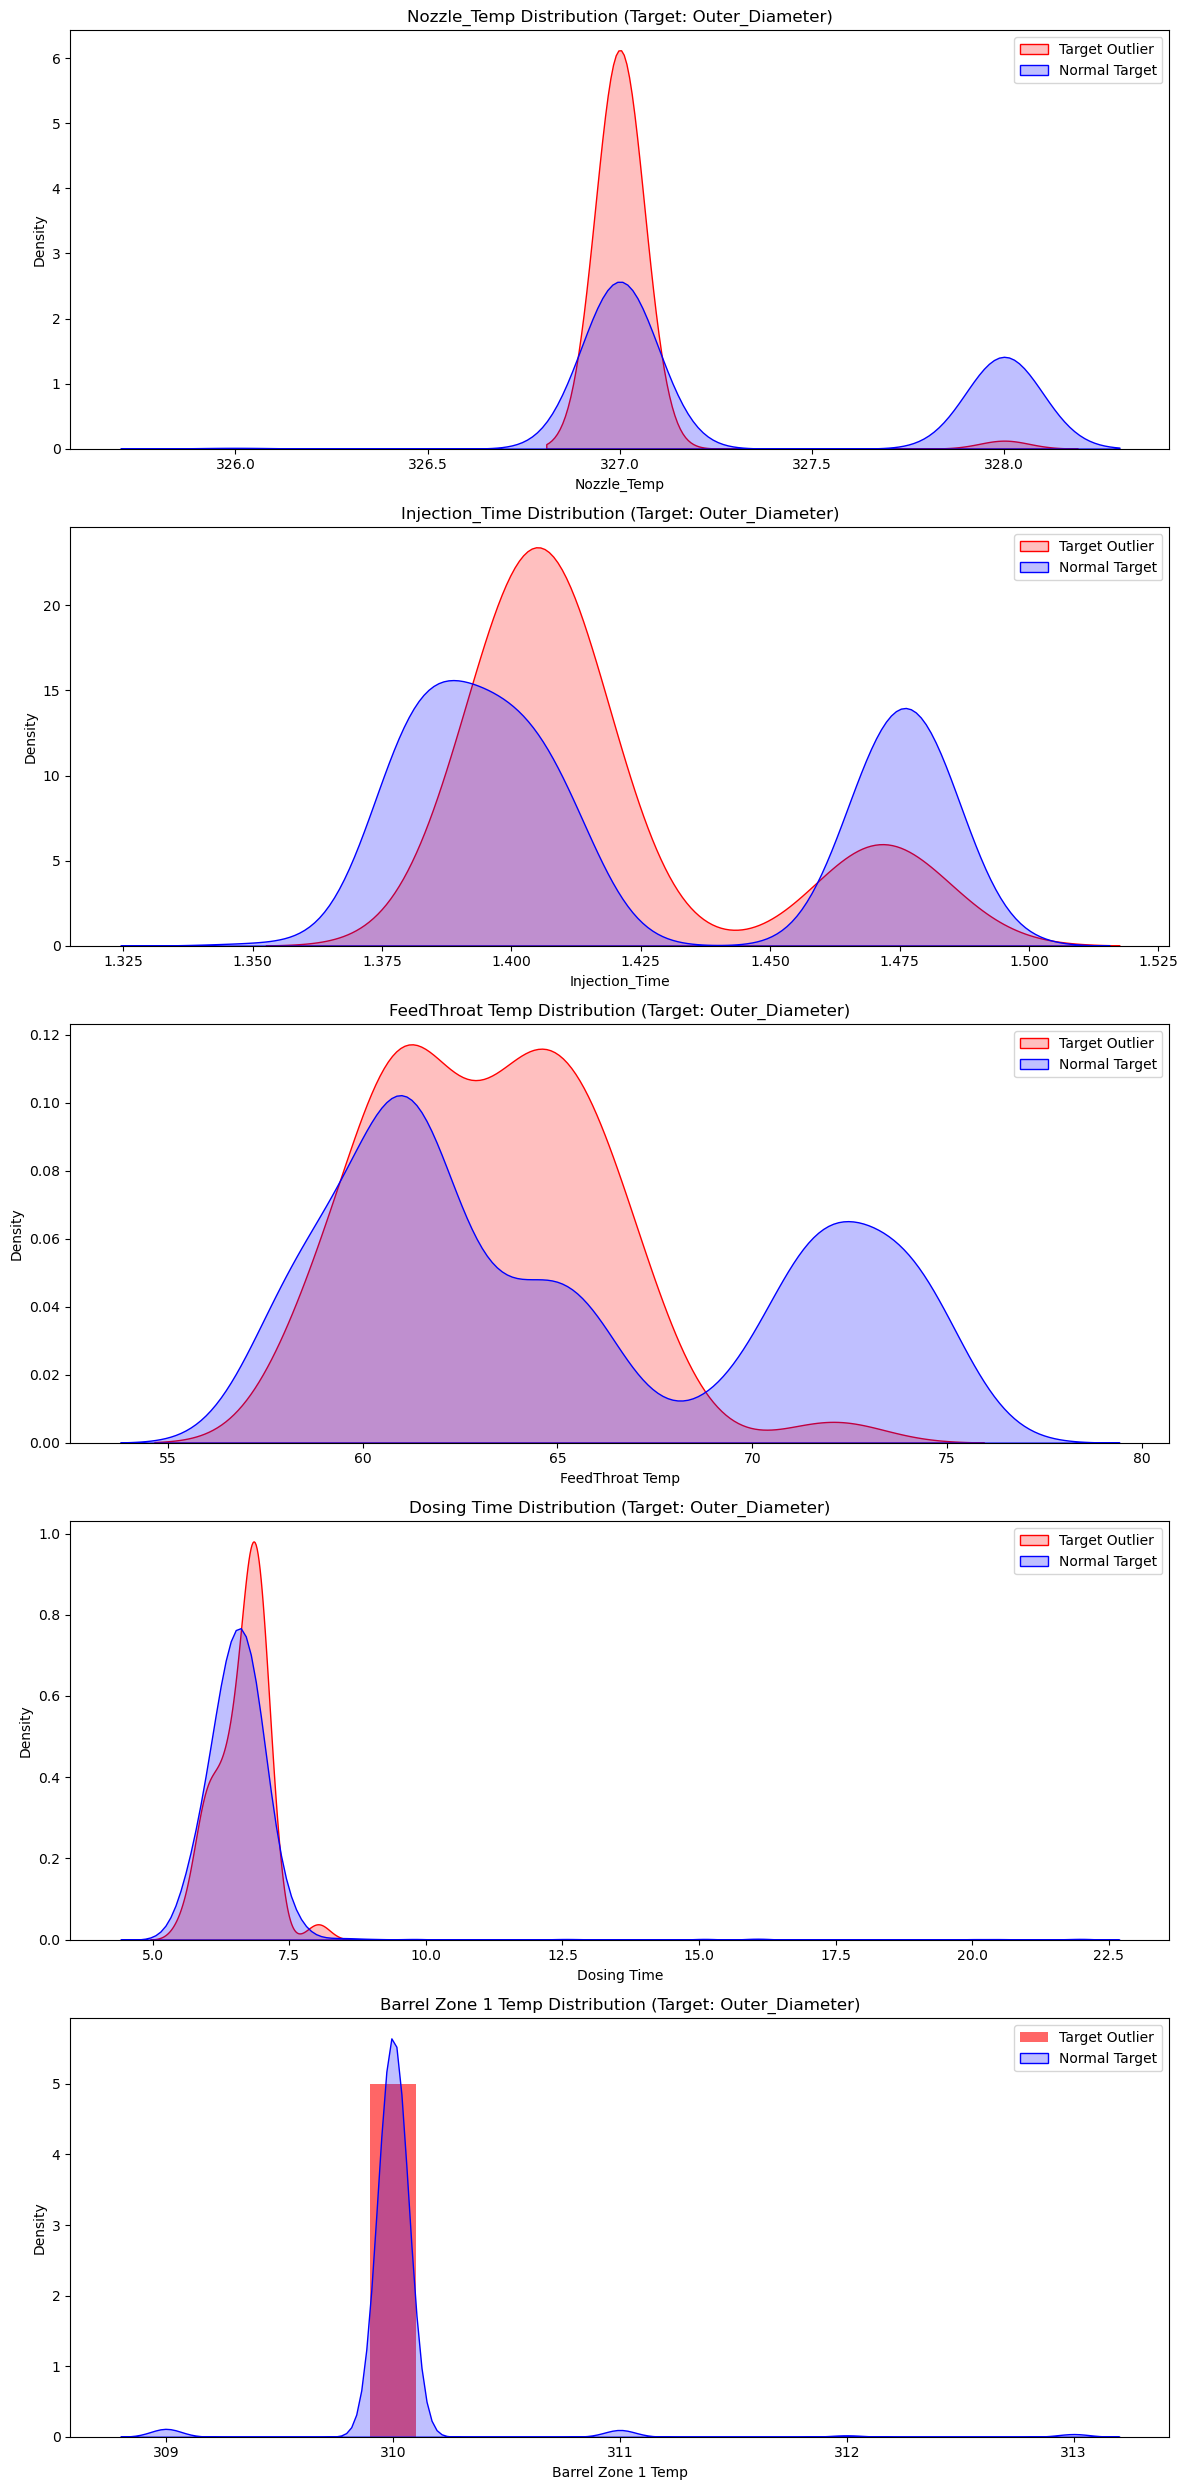

In [41]:
target = 'Outer_Diameter'
analyze_input_distributions_for_target_outliers_iforest(complete_df_total, target, inputs)

Number of outliers in Inner_Diameter (Isolation Forest): 0
Number of normal samples: 2707


C:\Users\aaron\anaconda3\Lib\site-packages\numpy\lib\histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
C:\Users\aaron\anaconda3\Lib\site-packages\numpy\lib\histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
C:\Users\aaron\anaconda3\Lib\site-packages\numpy\lib\histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
C:\Users\aaron\anaconda3\Lib\site-packages\numpy\lib\histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
C:\Users\aaron\anaconda3\Lib\site-packages\numpy\lib\histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


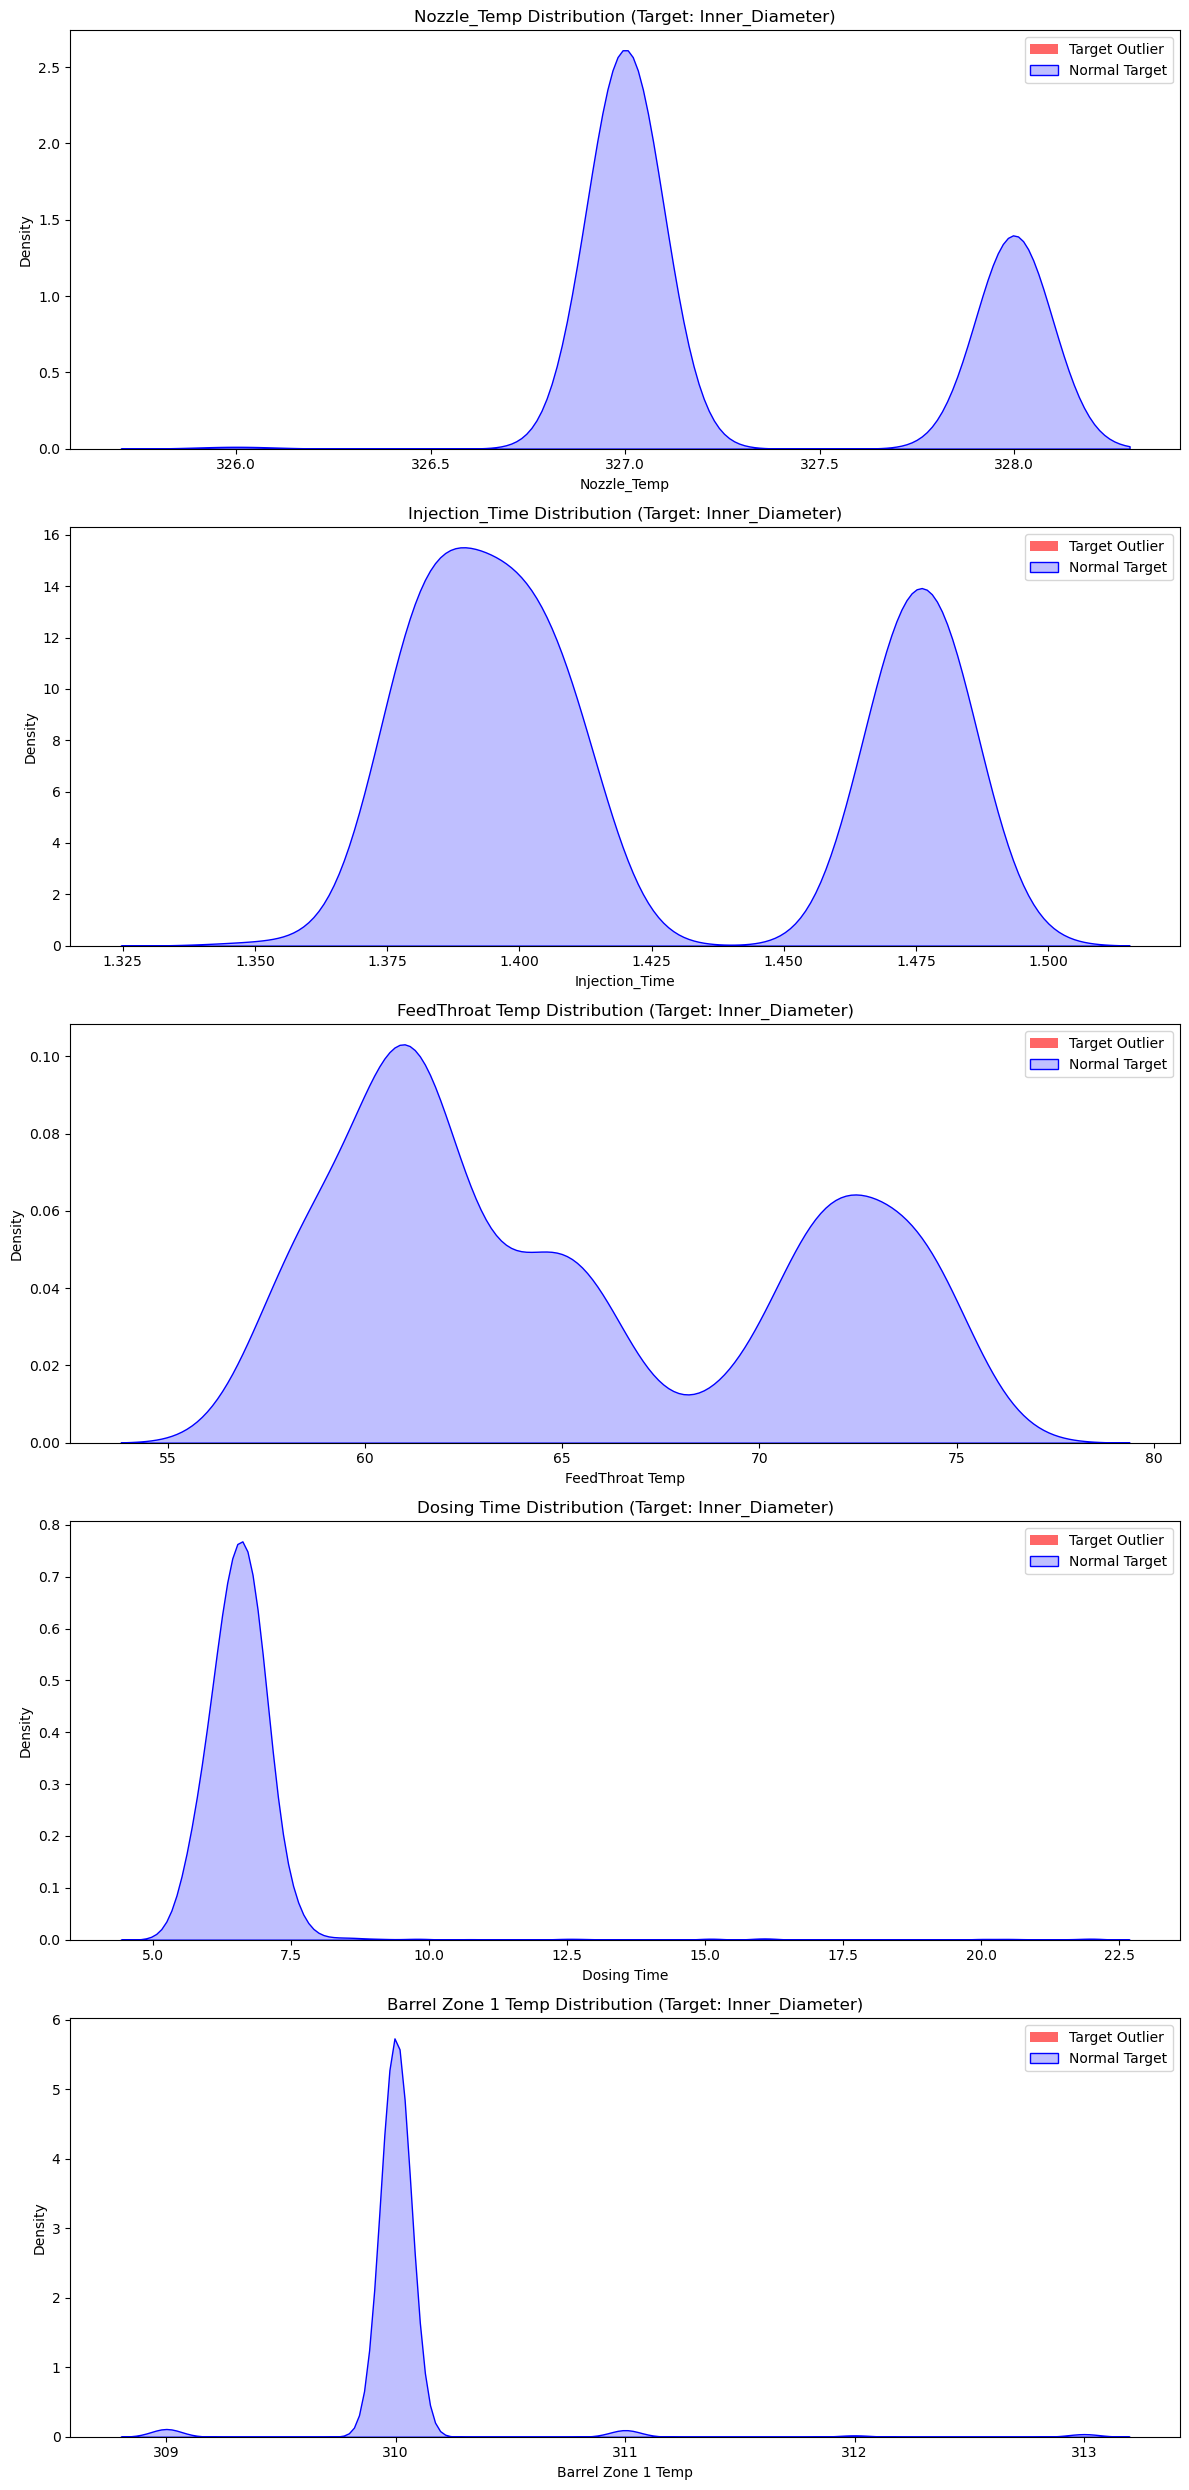

In [42]:
target = 'Inner_Diameter'
analyze_input_distributions_for_target_outliers_iforest(complete_df_total, target, inputs)

# Test Train Split

In [46]:
inputs  = ['Nozzle_Temp','Injection_Time','FeedThroat Temp','Dosing Time','Barrel Zone 1 Temp']
targets = ['Product_Thickness','Outer_Diameter','Inner_Diameter']

X = merged_total[inputs].copy()
y = merged_total[targets].copy()
X = X.fillna(X.median())
y = y.fillna(y.median())

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [47]:
from sklearn.metrics import mean_absolute_error

print("Baseline (predicting mean) MAE:")
for target in targets:
    # Use the average of the training set to predict the test set
    mean_pred = np.full_like(y_test[target], y_train[target].mean(), dtype=np.float64)
    mae = mean_absolute_error(y_test[target], mean_pred)
    print(f"{target}: {mae:.4f}")

Baseline (predicting mean) MAE:
Product_Thickness: 0.0131
Outer_Diameter: 0.0034
Inner_Diameter: 0.0042


In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Product_Thickness
rf1 = RandomForestRegressor(random_state=21)
rf1.fit(X_train_scaled, y_train['Product_Thickness'])
y1_pred = rf1.predict(X_test_scaled)

print("Product_Thickness")
print("MAE:", mean_absolute_error(y_test['Product_Thickness'], y1_pred))
print("R2:", r2_score(y_test['Product_Thickness'], y1_pred))

# Outer_Diameter
rf2 = RandomForestRegressor(random_state=21)
rf2.fit(X_train_scaled, y_train['Outer_Diameter'])
y2_pred = rf2.predict(X_test_scaled)

print("\nOuter_Diameter")
print("MAE:", mean_absolute_error(y_test['Outer_Diameter'], y2_pred))
print("R2:", r2_score(y_test['Outer_Diameter'], y2_pred))

# Inner_Diameter
rf3 = RandomForestRegressor(random_state=21)
rf3.fit(X_train_scaled, y_train['Inner_Diameter'])
y3_pred = rf3.predict(X_test_scaled)

print("\nInner_Diameter")
print("MAE:", mean_absolute_error(y_test['Inner_Diameter'], y3_pred))
print("R2:", r2_score(y_test['Inner_Diameter'], y3_pred))



Product_Thickness
MAE: 0.010915511835141205
R2: 0.23162163301351713

Outer_Diameter
MAE: 0.0026399351295885777
R2: 0.06572213051254394

Inner_Diameter
MAE: 0.0030256485162375806
R2: 0.11821758579070274


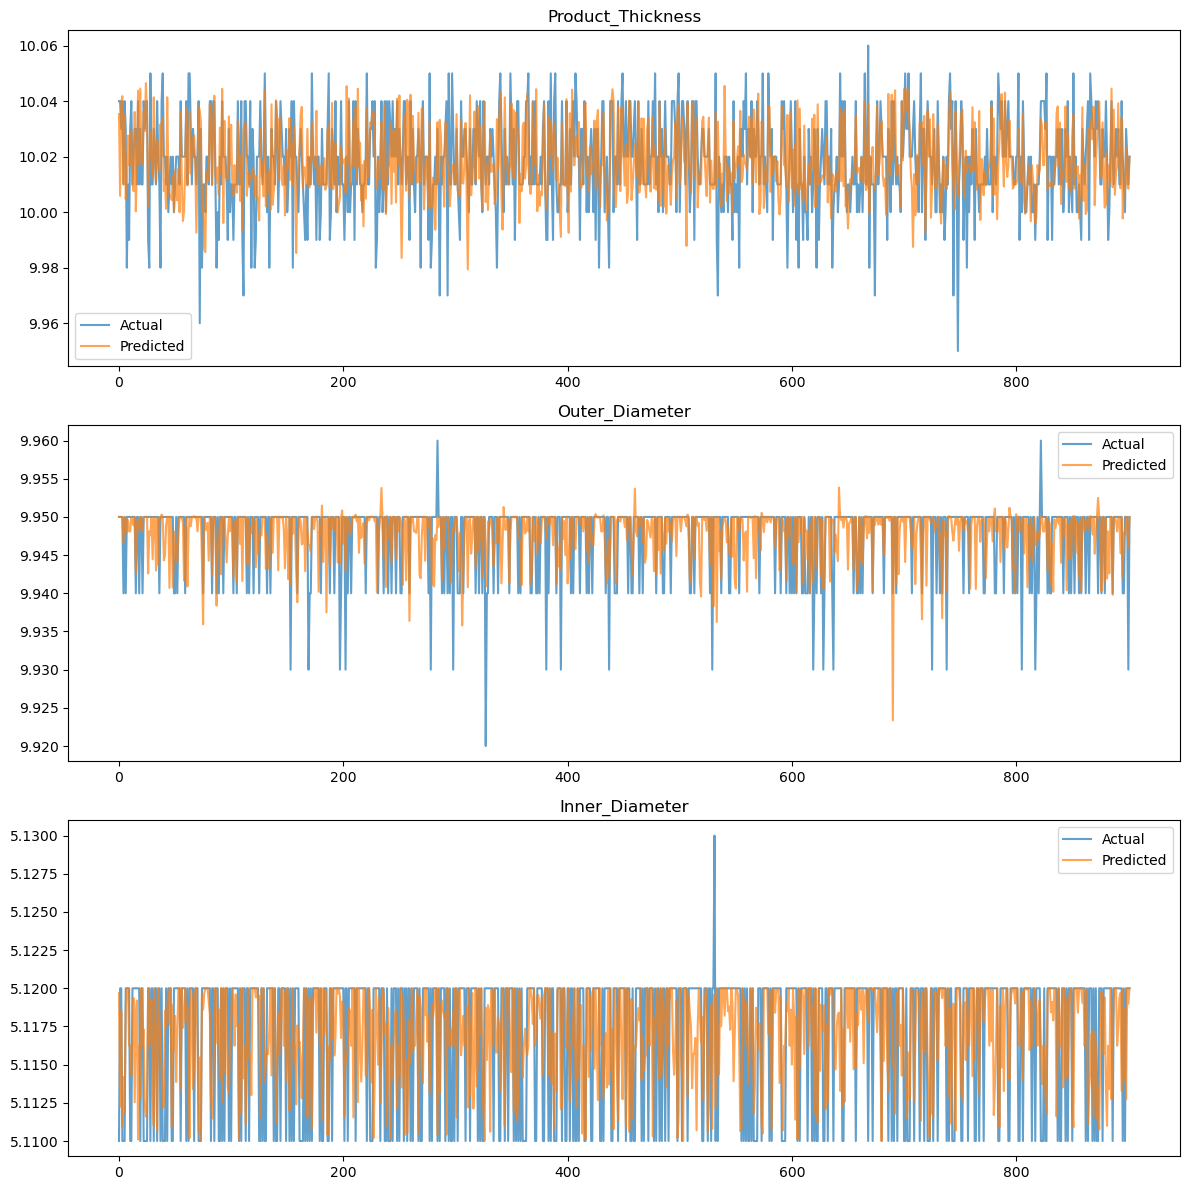

In [62]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].plot(y_test['Product_Thickness'].values, label='Actual', alpha=0.7)
axes[0].plot(y1_pred, label='Predicted', alpha=0.7)
axes[0].set_title('Product_Thickness')
axes[0].legend()

axes[1].plot(y_test['Outer_Diameter'].values, label='Actual', alpha=0.7)
axes[1].plot(y2_pred, label='Predicted', alpha=0.7)
axes[1].set_title('Outer_Diameter')
axes[1].legend()

axes[2].plot(y_test['Inner_Diameter'].values, label='Actual', alpha=0.7)
axes[2].plot(y3_pred, label='Predicted', alpha=0.7)
axes[2].set_title('Inner_Diameter')
axes[2].legend()

plt.tight_layout()
plt.show()

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# 1. Expanded parameter grid for better accuracy
param_grid = {
    'estimator__n_estimators': [50, 100, 200],
    'estimator__max_depth': [3, 5, 10, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],  # New parameter
    'estimator__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],  # New parameter
    'estimator__bootstrap': [True, False]  # New parameter
}

# 2. Create multi-target regressor
rf = RandomForestRegressor(
    random_state=21,
    n_jobs=-1  # Utilize all CPU cores
)
multi_rf = MultiOutputRegressor(rf)

# 3. GridSearchCV with MAE scoring
grid_search = GridSearchCV(
    estimator=multi_rf,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_absolute_error',  # MAE scoring
    refit=True,  # Refit best model on full training data
    n_jobs=-1,  # Parallelize search
    verbose=2  # Show progress during search
)
grid_search.fit(X_train_scaled, y_train)

# 4. Output best parameters
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")  # Convert negative MAE to positive

# 5. Prediction and comprehensive evaluation
y_pred = grid_search.predict(X_test_scaled)

print("\nTest Set Performance:")
print("{:<20} {:<10} {:<10} {:<10} {:<10}".format(
    "Target", "MAE", "RMSE", "R²", "MAPE(%)"
))

for i, target in enumerate(targets):
    # Calculate metrics
    mae = mean_absolute_error(y_test[target], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[target], y_pred[:, i]))
    r2 = r2_score(y_test[target], y_pred[:, i])
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    epsilon = 1e-10  # Avoid division by zero
    mape = 100 * np.mean(np.abs((y_test[target] - y_pred[:, i]) / 
                                (np.abs(y_test[target]) + epsilon)))
    
    print("{:<20} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.2f}".format(
        target, mae, rmse, r2, mape
    ))

# 6. Feature importance analysis
best_rf = grid_search.best_estimator_.estimators_[0]  # First target model
feature_importances = best_rf.feature_importances_

print("\nFeature Importances for first target:")
for feature, importance in zip(inputs, feature_importances):
    print(f"{feature}: {importance:.4f}")

Fitting 5 folds for each of 1080 candidates, totalling 5400 fits
Best Parameters: {'estimator__bootstrap': False, 'estimator__max_depth': 5, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 50}
Best CV MAE: 0.0051

Test Set Performance:
Target               MAE        RMSE       R²         MAPE(%)   
Product_Thickness    0.0095     0.0133     0.3699     0.09      
Outer_Diameter       0.0026     0.0041     0.2533     0.03      
Inner_Diameter       0.0030     0.0038     0.3054     0.06      

Feature Importances for first target:
Nozzle_Temp: 0.0395
Injection_Time: 0.5479
FeedThroat Temp: 0.3100
Dosing Time: 0.0999
Barrel Zone 1 Temp: 0.0027


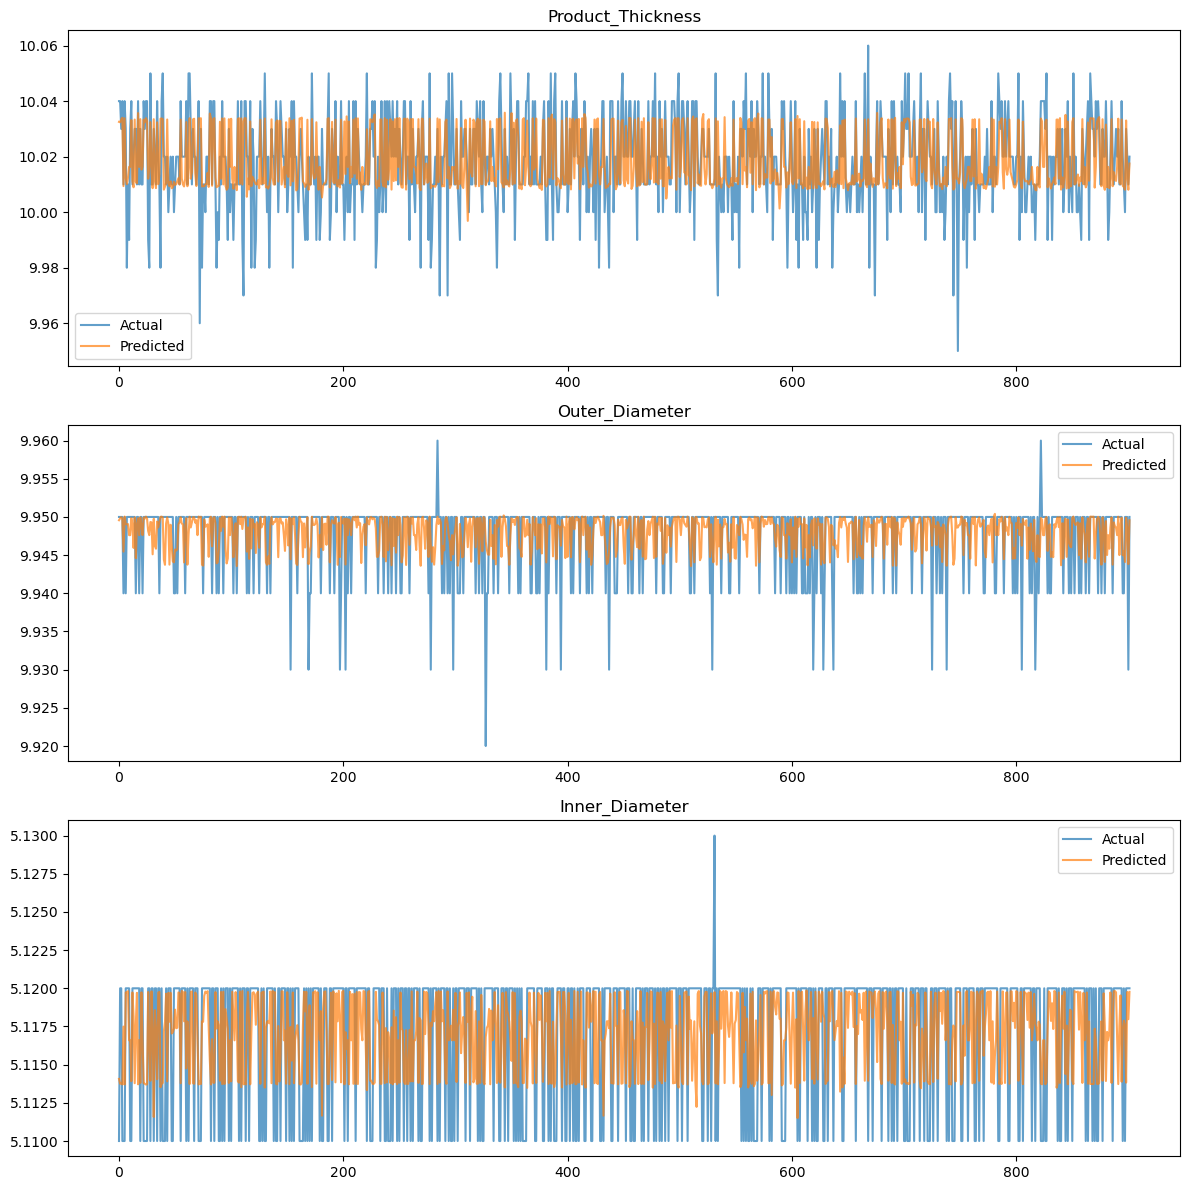

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Product_Thickness
axes[0].plot(y_test['Product_Thickness'].values, label='Actual', alpha=0.7)
axes[0].plot(y_pred[:, 0], label='Predicted', alpha=0.7)
axes[0].set_title('Product_Thickness')
axes[0].legend()

# Outer_Diameter
axes[1].plot(y_test['Outer_Diameter'].values, label='Actual', alpha=0.7)
axes[1].plot(y_pred[:, 1], label='Predicted', alpha=0.7)
axes[1].set_title('Outer_Diameter')
axes[1].legend()

# Inner_Diameter
axes[2].plot(y_test['Inner_Diameter'].values, label='Actual', alpha=0.7)
axes[2].plot(y_pred[:, 2], label='Predicted', alpha=0.7)
axes[2].set_title('Inner_Diameter')
axes[2].legend()

plt.tight_layout()
plt.show()

# Lightgbm

In [ ]:
!pip install lightgbm


=== Product_Thickness ===
Quantile: 0.1
MAE: 0.0168
Quantile: 0.5
MAE: 0.0095
First 5 predictions (Median): [10.03999996 10.03999996 10.03999996 10.03999996 10.01000023]
R2 score: 0.3001
Quantile: 0.9
MAE: 0.0144


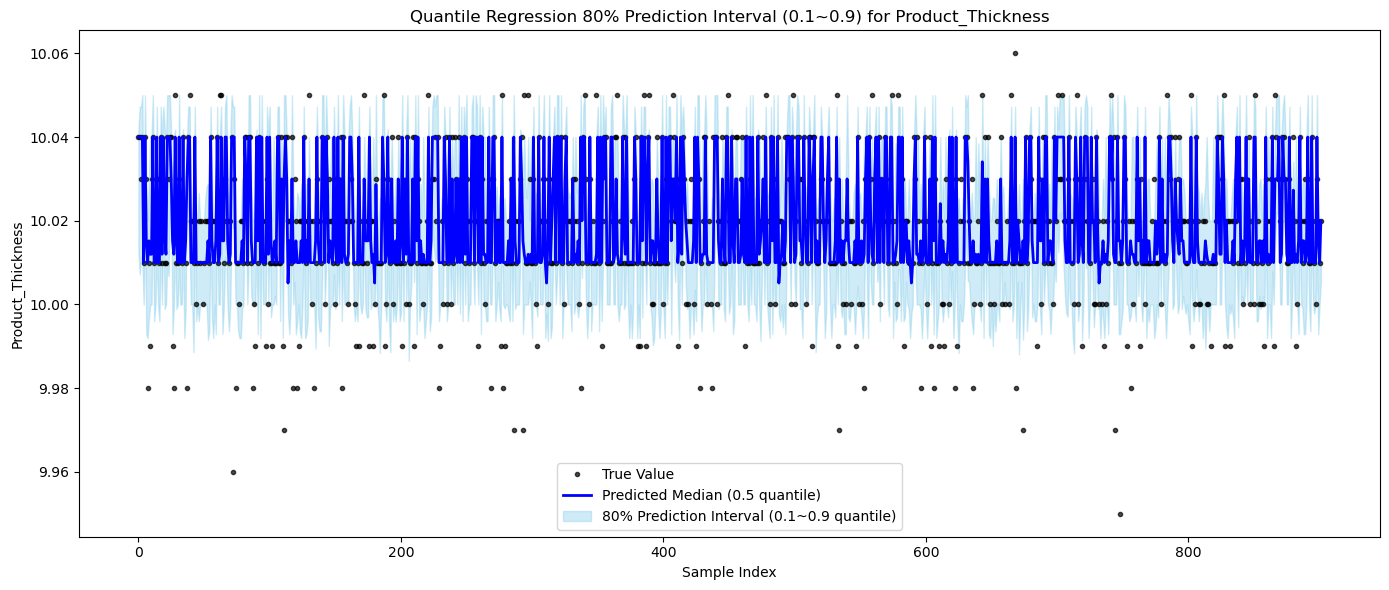


=== Outer_Diameter ===
Quantile: 0.1
MAE: 0.0036
Quantile: 0.5
MAE: 0.0022
First 5 predictions (Median): [9.94999981 9.94999981 9.94999981 9.94999981 9.94999981]
R2 score: -0.2120
Quantile: 0.9
MAE: 0.0022


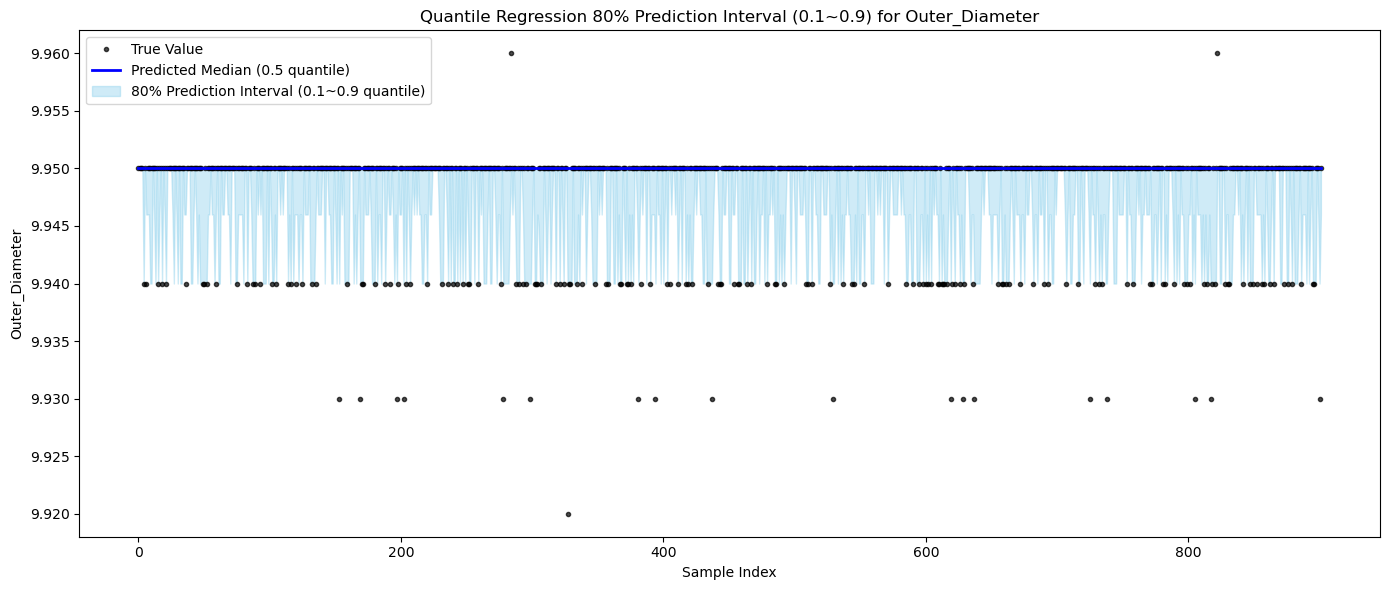


=== Inner_Diameter ===
Quantile: 0.1
MAE: 0.0041
Quantile: 0.5
MAE: 0.0029
First 5 predictions (Median): [5.11999989 5.11999989 5.11999989 5.11999989 5.11999989]
R2 score: -0.4028
Quantile: 0.9
MAE: 0.0029


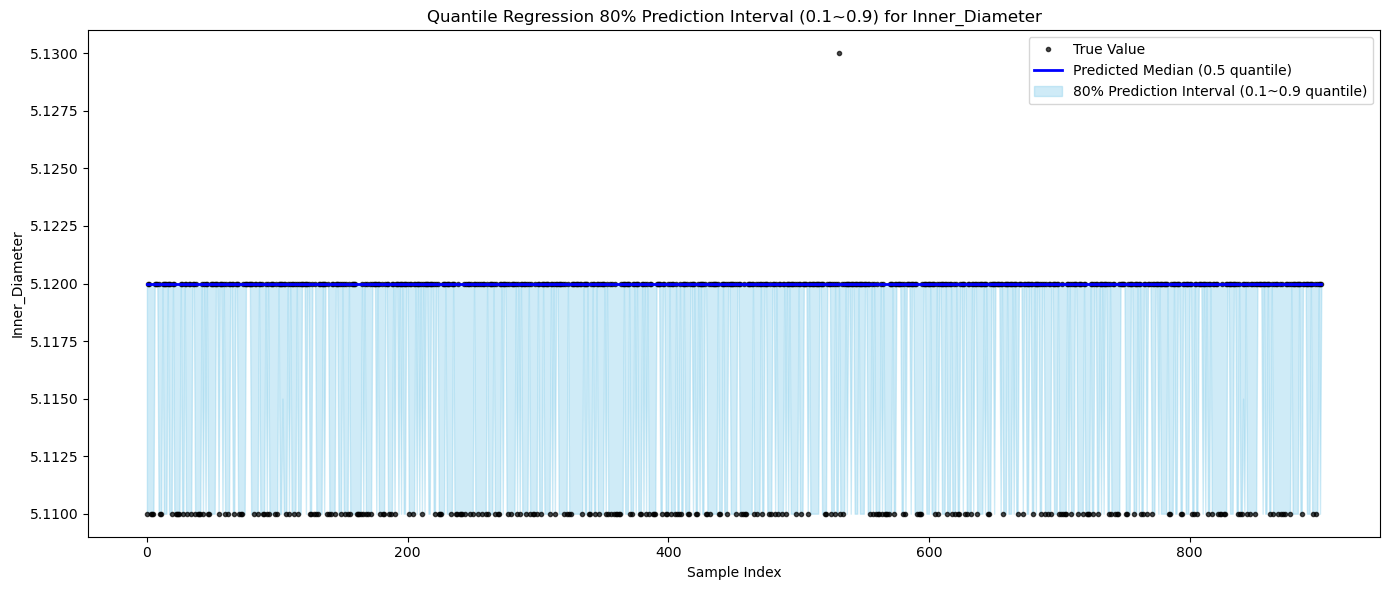

In [51]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import r2_score, mean_absolute_error
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

best_params = {
    'learning_rate': 0.2,
    'max_depth': 3,
    'min_child_samples': 5,
    'n_estimators': 100,
    'random_state': 42
}

targets = ['Product_Thickness', 'Outer_Diameter', 'Inner_Diameter']
alphas = [0.1, 0.5, 0.9]

for target in targets:
    preds = {}
    mae_results = {}
    print(f"\n=== {target} ===")
    for alpha in alphas:
        print(f"Quantile: {alpha}")
        model = lgb.LGBMRegressor(
            objective='quantile',
            alpha=alpha,
            verbose=-1,      
            **best_params
        )
        model.fit(X_train_scaled, y_train[target])
        preds[alpha] = model.predict(X_test_scaled)
        mae = mean_absolute_error(y_test[target], preds[alpha])
        mae_results[alpha] = mae
        print(f"MAE: {mae:.4f}")
        if alpha == 0.5:
            r2 = r2_score(y_test[target], preds[alpha])
            print("First 5 predictions (Median):", preds[alpha][:5])
            print(f"R2 score: {r2:.4f}")

    y_true = y_test[target].values
    plt.figure(figsize=(14,6))
    x = np.arange(len(y_true))
    plt.plot(x, y_true, 'k.', label='True Value', alpha=0.7)
    plt.plot(x, preds[0.5], 'b-', label='Predicted Median (0.5 quantile)', linewidth=2)
    plt.fill_between(x, preds[0.1], preds[0.9], color='skyblue', alpha=0.4, label='80% Prediction Interval (0.1~0.9 quantile)')
    plt.xlabel('Sample Index')
    plt.ylabel(target)
    plt.title(f'Quantile Regression 80% Prediction Interval (0.1~0.9) for {target}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [60]:
# Check if true values fall within the prediction interval (between 10th and 90th percentiles)
in_interval = (y_true >= preds[0.1]) & (y_true <= preds[0.9])

# Calculate coverage percentage
coverage = in_interval.mean()
print(f"{coverage*100:.2f}% of true values fall within the 80% prediction interval")

# Print counts of values inside and outside the interval
print(f"Total: {in_interval.sum()} values inside the interval, {len(y_true) - in_interval.sum()} values outside")

76.27% of true values fall within the 80% prediction interval
Total: 688 values inside the interval, 214 values outside


GridSearchCV for Product_Thickness ...
Best params for Product_Thickness: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31}
GridSearchCV for Outer_Diameter ...
Best params for Outer_Diameter: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'num_leaves': 15}
GridSearchCV for Inner_Diameter ...
Best params for Inner_Diameter: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'num_leaves': 15}

=== Product_Thickness ===
Quantile: 0.1
Quantile: 0.5
Quantile: 0.9
First 5 predictions (Quantile 0.1): [10.01522971 10.00200548 10.01561078 10.02036841  9.99727259]
First 5 predictions (Quantile 0.5): [10.03999943 10.02999976 10.02999976 10.02999976 10.01000049]
First 5 predictions (Quantile 0.9): [10.04999993 10.04999993 10.04999993 10.04999993 10.02000099]
First 5 true values: [10.04 10.04 10.03 10.04 10.01]
MAE (Median): 0.0092
80% prediction interval coverage: 73.17%


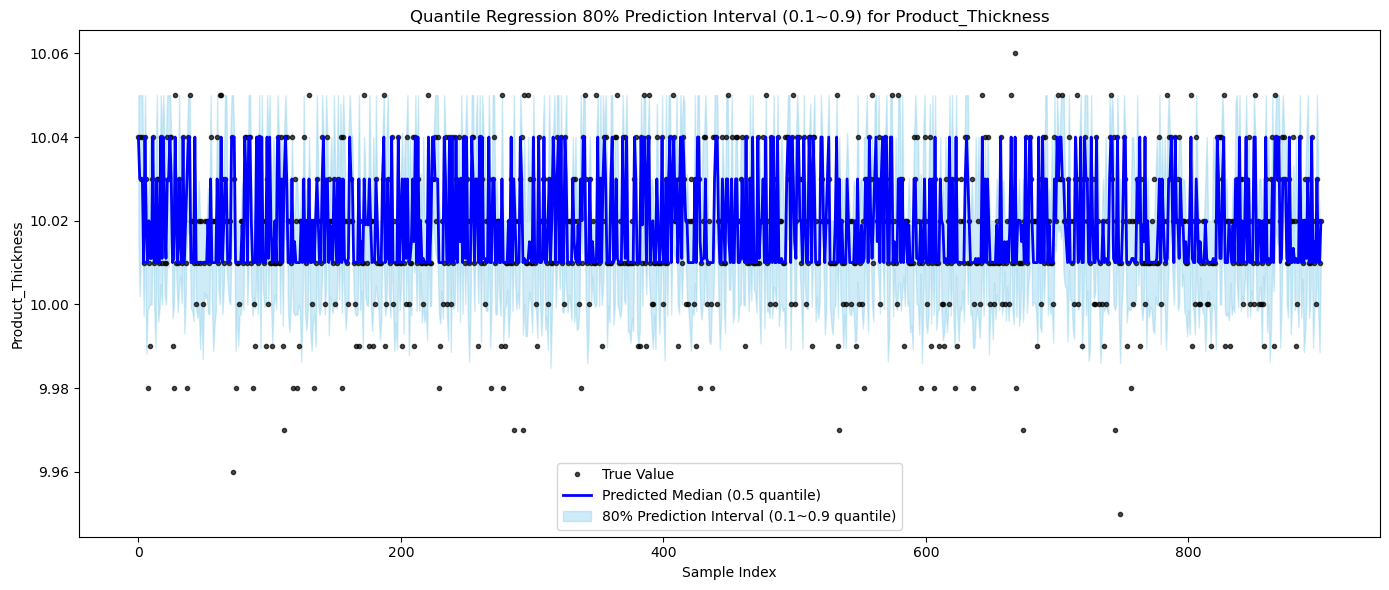


=== Outer_Diameter ===
Quantile: 0.1
Quantile: 0.5
Quantile: 0.9
First 5 predictions (Quantile 0.1): [9.94394961 9.94394961 9.94394961 9.94394961 9.93999958]
First 5 predictions (Quantile 0.5): [9.94999981 9.94999981 9.94999981 9.94999981 9.94999981]
First 5 predictions (Quantile 0.9): [9.94999981 9.94999981 9.94999981 9.94999981 9.94999981]
First 5 true values: [9.95 9.95 9.95 9.95 9.94]
MAE (Median): 0.0022
80% prediction interval coverage: 16.41%


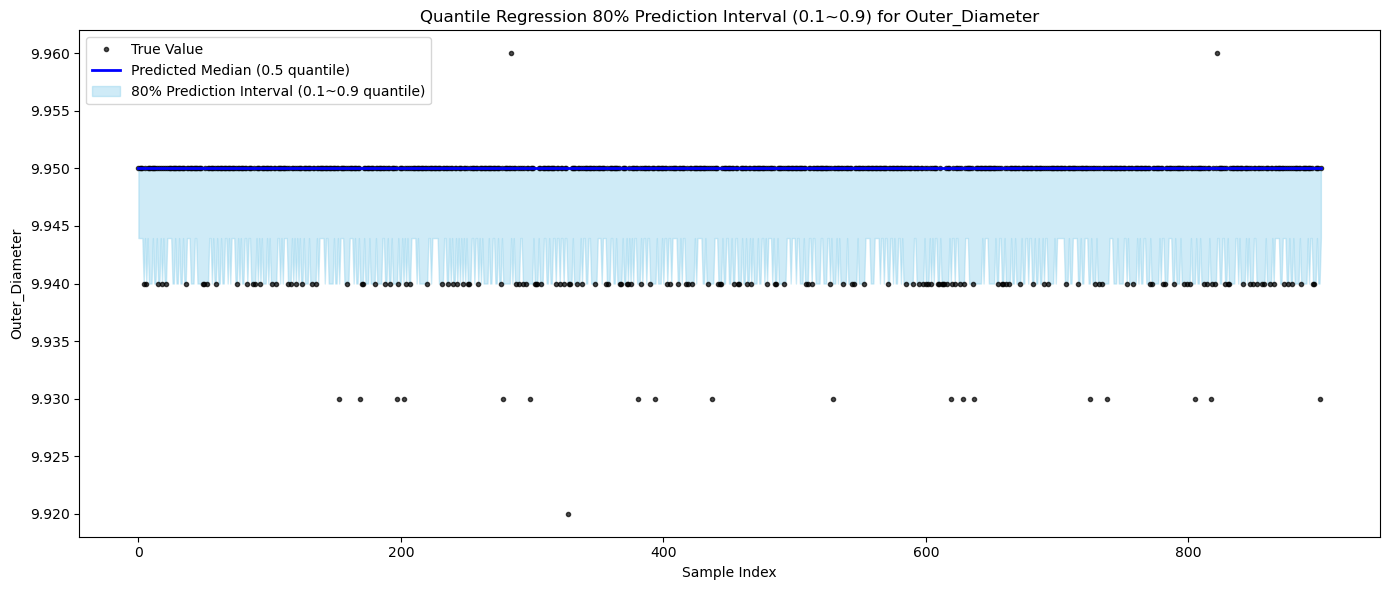


=== Inner_Diameter ===
Quantile: 0.1
Quantile: 0.5
Quantile: 0.9
First 5 predictions (Quantile 0.1): [5.11000013 5.11000013 5.11000013 5.11000013 5.11000013]
First 5 predictions (Quantile 0.5): [5.11999989 5.11999989 5.11999989 5.11999989 5.11999989]
First 5 predictions (Quantile 0.9): [5.11999989 5.11999989 5.11999989 5.11999989 5.11999989]
First 5 true values: [5.11 5.12 5.12 5.11 5.11]
MAE (Median): 0.0029
80% prediction interval coverage: 0.00%


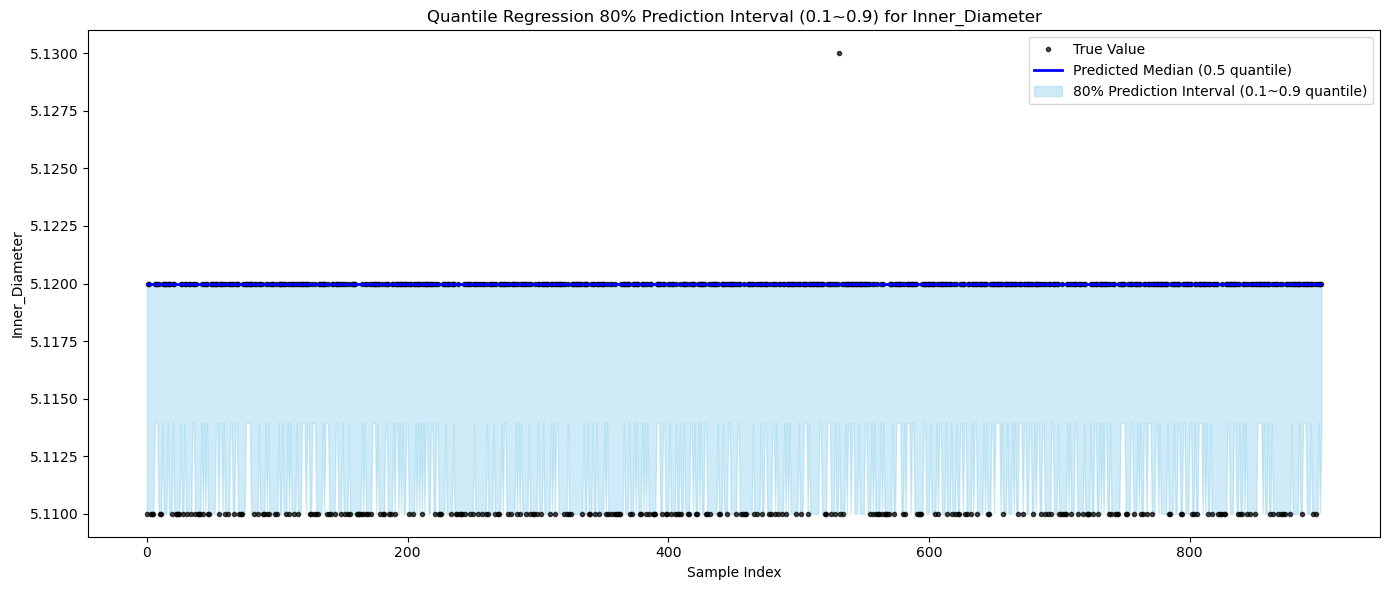

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

# Example: targets = ['Product_Thickness', 'Outer_Diameter', 'Inner_Diameter']
#          alphas = [0.1, 0.5, 0.9]

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63]
}

best_params_dict = {}

# Step 1: GridSearchCV for each target (using alpha=0.5, scoring by MAE)
for target in targets:
    print(f"GridSearchCV for {target} ...")
    base_model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=0.5,
        random_state=42,
        verbose=-1
    )
    grid = GridSearchCV(
        base_model,
        param_grid,
        scoring='neg_mean_absolute_error',  # MAE as scoring (negated for sklearn convention)
        cv=3,
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train[target])
    best_params_dict[target] = grid.best_params_
    print(f"Best params for {target}: {grid.best_params_}")

# Step 2: Quantile regression and interval coverage
for target in targets:
    preds = {}
    print(f"\n=== {target} ===")
    for alpha in alphas:
        print(f"Quantile: {alpha}")
        model = lgb.LGBMRegressor(
            objective='quantile',
            alpha=alpha,
            random_state=42,
            verbose=-1,
            **best_params_dict[target]
        )
        model.fit(X_train_scaled, y_train[target])
        preds[alpha] = model.predict(X_test_scaled)

    # Print the first 5 predictions for quantile 0.1, 0.5, and the true values
    print("First 5 predictions (Quantile 0.1):", preds[0.1][:5])
    print("First 5 predictions (Quantile 0.5):", preds[0.5][:5])
    print("First 5 predictions (Quantile 0.9):", preds[0.9][:5])
    print("First 5 true values:", y_test[target].values[:5])

    # Calculate MAE for median prediction
    mae = mean_absolute_error(y_test[target], preds[0.5])
    print(f"MAE (Median): {mae:.4f}")

    # Calculate prediction interval coverage
    y_true = y_test[target].values
    lower = preds[0.1]
    upper = preds[0.9]
    coverage = ((y_true >= lower) & (y_true <= upper)).mean()
    print(f"80% prediction interval coverage: {coverage*100:.2f}%")

    # Plotting
    plt.figure(figsize=(14, 6))
    x = np.arange(len(y_true))
    plt.plot(x, y_true, 'k.', label='True Value', alpha=0.7)
    plt.plot(x, preds[0.5], 'b-', label='Predicted Median (0.5 quantile)', linewidth=2)
    plt.fill_between(x, preds[0.1], preds[0.9], color='skyblue', alpha=0.4, label='80% Prediction Interval (0.1~0.9 quantile)')
    plt.xlabel('Sample Index')
    plt.ylabel(target)
    plt.title(f'Quantile Regression 80% Prediction Interval (0.1~0.9) for {target}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [59]:
# Check if true values fall within the prediction interval (between 10th and 90th percentiles)
in_interval = (y_true >= preds[0.1]) & (y_true <= preds[0.9])

# Calculate coverage percentage
coverage = in_interval.mean()
print(f"{coverage*100:.2f}% of true values fall within the 80% prediction interval")

# Print counts of values inside and outside the interval
print(f"Total: {in_interval.sum()} values inside the interval, {len(y_true) - in_interval.sum()} values outside")

76.27% of true values fall within the 80% prediction interval
Total: 688 values inside the interval, 214 values outside
